In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import ruptures as rpt
import matplotlib.pyplot as plt
from statsmodels.regression.recursive_ls import RecursiveLS
from scipy.stats import f
import time
import warnings
warnings.filterwarnings('ignore')

## **1. Enfoque Econométrico y de Series Temporales (Los "Clásicos")**

In [16]:
# 1. descarga
spx = yf.download("^GSPC", start="2005-01-01", end="2024-12-31", auto_adjust=True)
# yfinance a veces devuelve columnas multiíndice
if isinstance(spx.columns, pd.MultiIndex):
    spx.columns = spx.columns.droplevel(1)

spx['ret'] = np.log(spx['Close']).diff()
spx['ret_lag'] = spx['ret'].shift(1)
spx = spx.dropna()

# 2. función Chow corregida
def chow_test(df, break_date):
    df = df.copy()
    df['post'] = (df.index >= pd.Timestamp(break_date)).astype(int)

    X = sm.add_constant(df[['ret_lag']])
    y = df['ret']

    pooled = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':5})
    pre = sm.OLS(y[df['post']==0], X[df['post']==0]).fit(cov_type='HAC', cov_kwds={'maxlags':5})
    post = sm.OLS(y[df['post']==1], X[df['post']==1]).fit(cov_type='HAC', cov_kwds={'maxlags':5})

    ssr_p, ssr1, ssr2 = pooled.ssr, pre.ssr, post.ssr
    n1, n2, k = int(pre.nobs), int(post.nobs), X.shape[1]

    F = ((ssr_p - (ssr1+ssr2)) / k) / ((ssr1+ssr2) / (n1 + n2 - 2*k))
    pval = 1 - f.cdf(F, dfn=k, dfd=n1+n2-2*k) # <- aquí estaba el fallo

    return {
        'F': round(F, 4),
        'p-value': round(pval, 6),
        'n1': n1, 'n2': n2,
        'pre_alpha': round(pre.params['const'], 6),
        'post_alpha': round(post.params['const'], 6),
        'pre_phi': round(pre.params['ret_lag'], 4),
        'post_phi': round(post.params['ret_lag'], 4)
    }

# 3. aplica
chow_2008 = chow_test(spx.loc['2006-01-01':'2010-12-31'], '2008-09-15')
chow_covid = chow_test(spx.loc['2018-01-01':'2021-12-31'], '2020-03-11')

print("2008:", chow_2008)
print("Covid:", chow_covid)

[*********************100%***********************]  1 of 1 completed

2008: {'F': np.float64(0.0436), 'p-value': np.float64(0.957376), 'n1': 679, 'n2': 580, 'pre_alpha': np.float64(3e-06), 'post_alpha': np.float64(1e-05), 'pre_phi': np.float64(-0.1406), 'post_phi': np.float64(-0.1207)}
Covid: {'F': np.float64(8.7269), 'p-value': np.float64(0.000175), 'n1': 550, 'n2': 458, 'pre_alpha': np.float64(0.00014), 'post_alpha': np.float64(0.001499), 'pre_phi': np.float64(-0.0829), 'post_phi': np.float64(-0.3312)}


In [ ]:
# 1. crea la serie de volatilidad
spx['vol'] = np.log(spx['ret'].abs() + 1e-8) # +1e-8 evita log(0)
spx['vol_lag'] = spx['vol'].shift(1)
spx = spx.dropna()

# 2. función Chow para volatilidad
def chow_vol_test(df, break_date, window_name=""):
    df = df.copy()
    df['post'] = (df.index >= pd.Timestamp(break_date)).astype(int)

    X = sm.add_constant(df[['vol_lag']])
    y = df['vol']

    pooled = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':5})
    pre = sm.OLS(y[df['post']==0], X[df['post']==0]).fit(cov_type='HAC', cov_kwds={'maxlags':5})
    post = sm.OLS(y[df['post']==1], X[df['post']==1]).fit(cov_type='HAC', cov_kwds={'maxlags':5})

    ssr_p, ssr1, ssr2 = pooled.ssr, pre.ssr, post.ssr
    n1, n2, k = int(pre.nobs), int(post.nobs), X.shape[1]

    F = ((ssr_p - (ssr1+ssr2)) / k) / ((ssr1+ssr2) / (n1 + n2 - 2*k))
    pval = 1 - f.cdf(F, dfn=k, dfd=n1+n2-2*k)

    return {
        'ventana': window_name,
        'F': round(F, 4),
        'p-value': round(pval, 6),
        'n1': n1, 'n2': n2,
        'pre_alpha': round(pre.params['const'], 4),
        'post_alpha': round(post.params['const'], 4),
        'pre_phi': round(pre.params['vol_lag'], 4),
        'post_phi': round(post.params['vol_lag'], 4)
    }

# 3. aplica en las mismas ventanas que usaste
vol_2008 = chow_vol_test(spx.loc['2006-01-01':'2010-12-31'], '2008-09-15', '2008')
vol_covid = chow_vol_test(spx.loc['2018-01-01':'2021-12-31'], '2020-03-11', 'Covid')

print("Vol 2008:", vol_2008)
print("Vol Covid:", vol_covid)

Vol 2008: {'ventana': '2008', 'F': np.float64(20.8627), 'p-value': np.float64(0.0), 'n1': 679, 'n2': 580, 'pre_alpha': np.float64(-5.3205), 'post_alpha': np.float64(-4.0759), 'pre_phi': np.float64(0.0331), 'post_phi': np.float64(0.186)}
Vol Covid: {'ventana': 'Covid', 'F': np.float64(9.0727), 'p-value': np.float64(0.000124), 'n1': 550, 'n2': 458, 'pre_alpha': np.float64(-4.9551), 'post_alpha': np.float64(-3.8234), 'pre_phi': np.float64(0.1096), 'post_phi': np.float64(0.2704)}


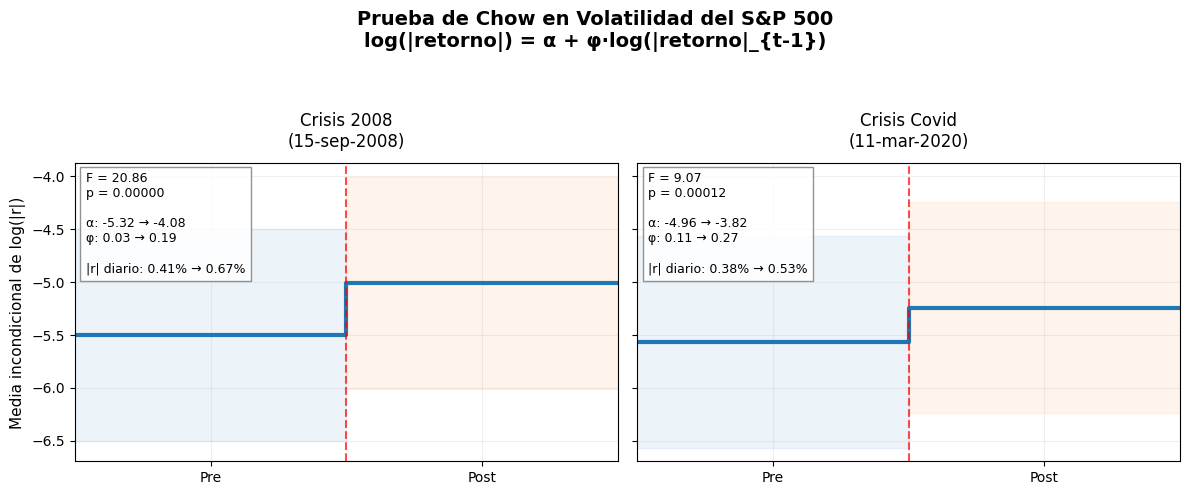

In [22]:
# --- 1. USA TUS DICCIONARIOS Y RENOMBRA LAS LLAVES ---
def to_plot_dict(d, titulo):
    return {
        "title": titulo,
        "F": d["F"],
        "p": d["p-value"], # <- aquí estaba el choque
        "pre_alpha": d["pre_alpha"],
        "post_alpha": d["post_alpha"],
        "pre_phi": d["pre_phi"],
        "post_phi": d["post_phi"],
    }

cases = [
    to_plot_dict(vol_2008, "Crisis 2008\n(15-sep-2008)"),
    to_plot_dict(vol_covid, "Crisis Covid\n(11-mar-2020)"),
]

# --- 2. CALCULA MEDIAS (igual que antes) ---
for c in cases:
    c["pre_mu"] = c["pre_alpha"] / (1 - c["pre_phi"])
    c["post_mu"] = c["post_alpha"] / (1 - c["post_phi"])
    c["pre_vol"] = np.exp(c["pre_mu"]) * 100
    c["post_vol"] = np.exp(c["post_mu"]) * 100

# --- 3. GRAFICA (sin cambios) ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.suptitle(
    "Prueba de Chow en Volatilidad del S&P 500\n"
    "log(|retorno|) = α + φ·log(|retorno|_{t-1})",
    fontsize=14, weight='bold'
)

for ax, c in zip(axs, cases):
    x = [0, 1, 1, 2]
    y = [c["pre_mu"], c["pre_mu"], c["post_mu"], c["post_mu"]]
    ax.plot(x, y, linewidth=3, color="#1f77b4")
    ax.axvline(1, color="red", linestyle="--", alpha=0.7, linewidth=1.5)
    ax.fill_between([0,1], c["pre_mu"]-1, c["pre_mu"]+1, alpha=0.08, color="#1f77b4")
    ax.fill_between([1,2], c["post_mu"]-1, c["post_mu"]+1, alpha=0.08, color="#ff7f0e")

    ax.set_title(c["title"], fontsize=12, pad=12)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(["Pre", "Post"])
    ax.set_xlim(0, 2)
    ax.grid(alpha=0.2)

    txt = (
        f"F = {c['F']:.2f}\n"
        f"p = {c['p']:.5f}\n\n"
        f"α: {c['pre_alpha']:.2f} → {c['post_alpha']:.2f}\n"
        f"φ: {c['pre_phi']:.2f} → {c['post_phi']:.2f}\n\n"
        f"|r| diario: {c['pre_vol']:.2f}% → {c['post_vol']:.2f}%"
    )
    ax.text(0.02, 0.97, txt, transform=ax.transAxes, va="top", ha="left",
            fontsize=9, bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray"))

axs[0].set_ylabel("Media incondicional de log(|r|)", fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("chow_volatilidad_2008_covid.png", dpi=200, bbox_inches="tight")
plt.show()

[*********************100%***********************]  1 of 1 completed


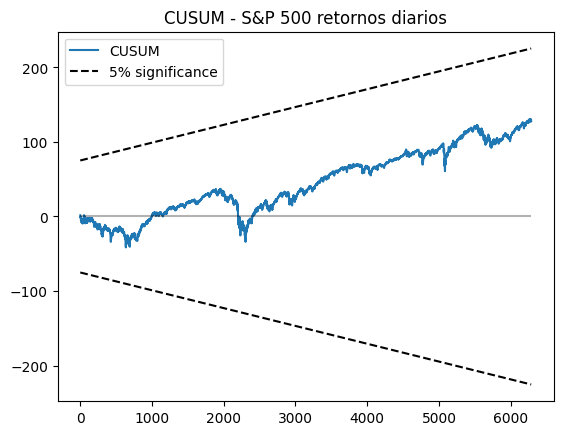

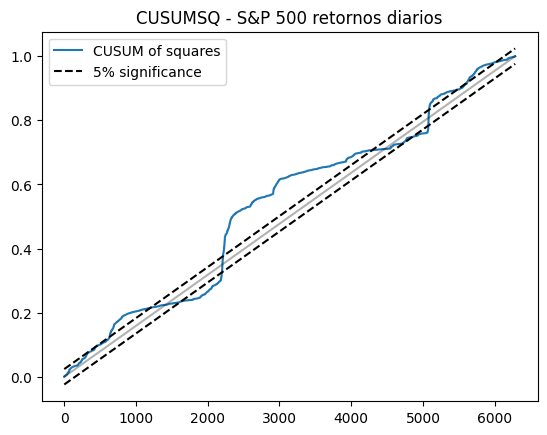

In [48]:
# 1. Descargar datos
spx = yf.download("^GSPC",
                  start="2000-01-01",
                  end="2024-12-31",
                  auto_adjust=True)

# 2. Calcular retornos logarítmicos
spx["ret"] = np.log(spx["Close"]).diff()

# 3. Construir DataFrame para el modelo AR(1)
data = pd.DataFrame({
    "y": spx["ret"],
    "lag1": spx["ret"].shift(1)
})

# 4. Eliminar NaN e infinitos
data = data.replace([np.inf, -np.inf], np.nan).dropna()

# 5. Variables del modelo
y = data["y"]
X = sm.add_constant(data["lag1"])

# 6. Ajustar Recursive Least Squares
mod = RecursiveLS(y, X)
res = mod.fit()

# 7. Gráfico CUSUM
res.plot_cusum(alpha=0.05)
plt.title("CUSUM - S&P 500 retornos diarios")
plt.show()

# 8. Gráfico CUSUMSQ
res.plot_cusum_squares(alpha=0.05)
plt.title("CUSUMSQ - S&P 500 retornos diarios")
plt.show()

# 9. Estadísticos
cusum = res.cusum
cusumsq = res.cusum_squares

[*********************100%***********************]  1 of 1 completed


Primer cruce arriba: 2001-04-18
Primer cruce abajo: 2006-07-18

Cruce 2008: 2008-10-22
Cruce Covid: 2020-03-18


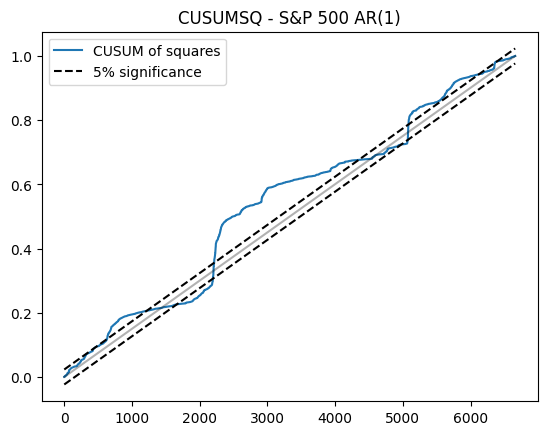

In [49]:
# 1. datos
spx = yf.download("^GSPC", start="2000-01-01", end="2026-12-31", auto_adjust=True)
spx["ret"] = np.log(spx["Close"]).diff()
data = spx.dropna()

# 2. modelo AR(1) - OPCIÓN B
y = data["ret"].iloc[1:]
X = sm.add_constant(data["ret"].shift(1).iloc[1:])

mod = RecursiveLS(y, X)
res = mod.fit()

# 3. CUSUMSQ
cusumsq = res.cusum_squares
k = X.shape[1]
dates = y.index[k:] # alinea fechas con cusumsq

# 4. bandas al 5% (fórmula de statsmodels)
d = max(res.nobs_diffuse, res.loglikelihood_burn)
n = 0.5 * (res.nobs - d) - 1

# escalares para alpha=0.05
scalars = np.array([1.2238734, -0.6700069, -0.7351697]) # de _cusum_squares_scalars【6208677556099917731†L8-L12】
crit = scalars[0]/np.sqrt(n) + scalars[1]/n + scalars[2]/n**1.5

points = np.arange(d, res.nobs)
line = (points - d) / (res.nobs - d)
lower = line - crit
upper = line + crit

# alinea bandas con cusumsq
lower_s = pd.Series(lower, index=dates[-len(lower):])
upper_s = pd.Series(upper, index=dates[-len(upper):])
cusum_s = pd.Series(cusumsq, index=dates[-len(cusumsq):])

# 5. cruces
cross_up = cusum_s[cusum_s > upper_s]
cross_down = cusum_s[cusum_s < lower_s]

print("Primer cruce arriba:", cross_up.index[0].date())
if not cross_down.empty:
    print("Primer cruce abajo:", cross_down.index[0].date())

# cruces en crisis
c2008 = cross_up[(cross_up.index >= "2007-01-01") & (cross_up.index <= "2009-12-31")]
c2020 = cross_up[(cross_up.index >= "2019-01-01") & (cross_up.index <= "2021-12-31")]

print("\nCruce 2008:", c2008.index[0].date() if not c2008.empty else "no")
print("Cruce Covid:", c2020.index[0].date() if not c2020.empty else "no")

# 6. gráfico
fig = res.plot_cusum_squares(alpha=0.05)
plt.title("CUSUMSQ - S&P 500 AR(1)")
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


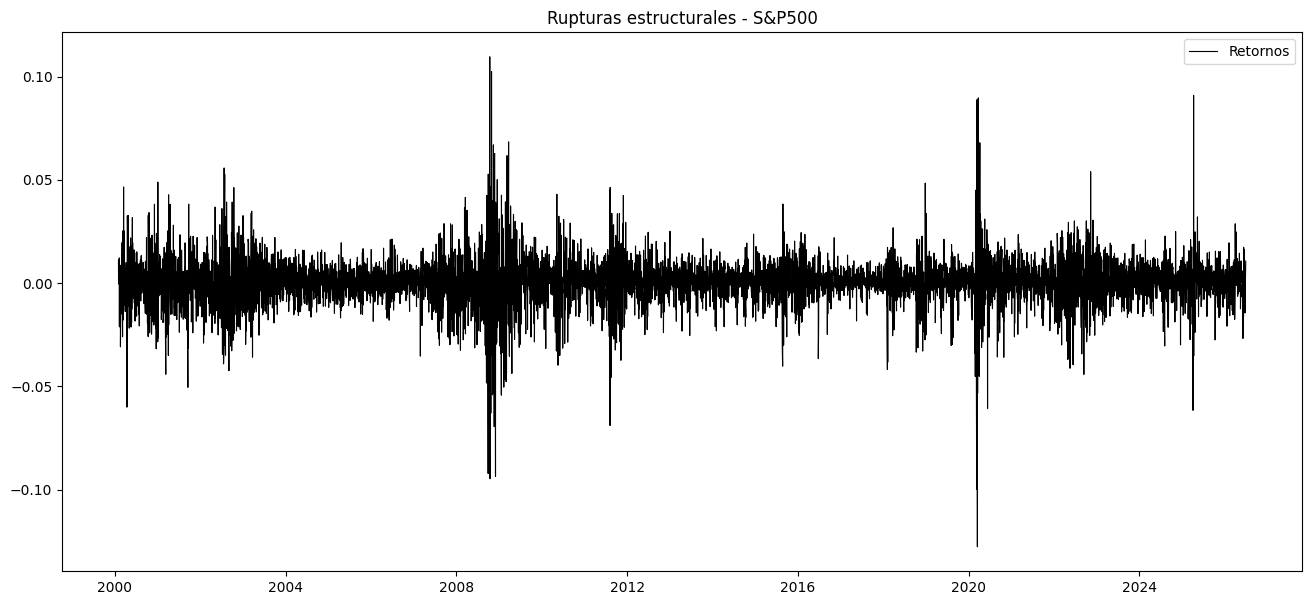



REGIMEN 1
2000-02-01 -> 2026-06-29
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                     474.2
Date:               lun, 29 Jun. 2026   Prob (F-statistic):               0.00
Time:                        13:00:50   Log-Likelihood:                 20883.
No. Observations:                6641   AIC:                        -4.175e+04
Df Residuals:                    6635   BIC:                        -4.171e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          

In [60]:
import yfinance as yf
import pandas as pd
import numpy as np
import ruptures as rpt
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ==========================================================
# 1. Descargar datos
# ==========================================================

spx = yf.download(
    "^GSPC",
    start="2000-01-01",
    end="2026-12-31",
    auto_adjust=True
)

vix = yf.download(
    "^VIX",
    start="2000-01-01",
    end="2026-12-31",
    auto_adjust=True
)

# ==========================================================
# 2. Construcción de variables
# ==========================================================

df = pd.DataFrame(index=spx.index)

df["close"] = spx["Close"]

df["ret"] = np.log(df["close"]).diff()

df["lag1"] = df["ret"].shift(1)
df["lag2"] = df["ret"].shift(2)

# volatilidad realizada
df["vol20"] = df["ret"].rolling(20).std()

# tendencia
df["ma20"] = df["close"] / df["close"].rolling(20).mean() - 1

# VIX
df["vix"] = vix["Close"]

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# ==========================================================
# 3. Variables del modelo
# ==========================================================

y = df["ret"].values

X = df[
    [
        "lag1",
        "lag2",
        "vol20",
        "ma20",
        "vix"
    ]
].values

# Normalizar variables
scaler = StandardScaler()
X = scaler.fit_transform(X)

# agregar constante
X = sm.add_constant(X)

# ==========================================================
# 4. Señal para ruptures
# ==========================================================

signal = np.column_stack([y, X])

algo = rpt.Pelt(
    model="linear",
    min_size=126,
    jump=5
).fit(signal)

pen = 5 * np.log(len(y))

bkps = algo.predict(pen=pen)

# ==========================================================
# 5. Graficar rupturas
# ==========================================================

plt.figure(figsize=(16,7))

plt.plot(
    df.index,
    df["ret"],
    color="black",
    lw=0.8,
    label="Retornos"
)

for b in bkps[:-1]:
    plt.axvline(
        df.index[b],
        color="red",
        linestyle="--",
        alpha=0.8
    )

plt.title("Rupturas estructurales - S&P500")
plt.legend()
plt.show()

# ==========================================================
# 6. Estimar cada régimen
# ==========================================================

resultados = []

print("="*80)

for i, b in enumerate(bkps):

    inicio = 0 if i == 0 else bkps[i-1]
    fin = b

    yr = y[inicio:fin]
    Xr = X[inicio:fin]

    modelo = sm.OLS(yr, Xr).fit()

    print("\n")
    print("="*80)
    print(f"REGIMEN {i+1}")
    print(df.index[inicio].date(), "->", df.index[fin-1].date())
    print("="*80)

    print(modelo.summary())

    resultados.append({

        "Inicio": df.index[inicio].date(),

        "Fin": df.index[fin-1].date(),

        "Observaciones": len(yr),

        "Intercepto": modelo.params[0],

        "Lag1": modelo.params[1],

        "Lag2": modelo.params[2],

        "Vol20": modelo.params[3],

        "MA20": modelo.params[4],

        "VIX": modelo.params[5],

        "R2": modelo.rsquared,

        "AdjR2": modelo.rsquared_adj,

        "AIC": modelo.aic,

        "BIC": modelo.bic

    })

# ==========================================================
# 7. Guardar resultados
# ==========================================================

tabla = pd.DataFrame(resultados)

tabla.to_csv(
    "regimenes_sp500.csv",
    index=False
)

print("\n")
print("="*80)
print("Quiebres encontrados")
print("="*80)

for b in bkps[:-1]:
    print(df.index[b].date())

print("\n")
print("="*80)
print(tabla)

Descargando datos...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


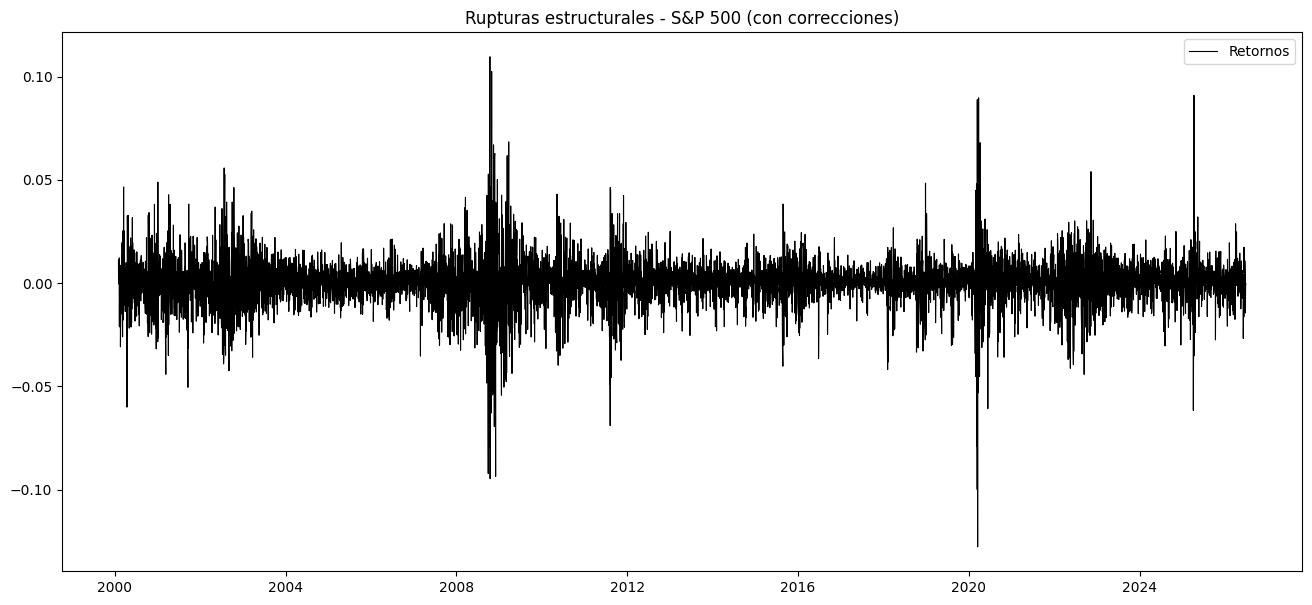


ESTIMACIÓN POR REGÍMENES CON RIDGE (L2)

--------------------------------------------------------------------------------
RÉGIMEN 1
Periodo: 2000-02-01 -> 2026-06-26
Observaciones: 6640
Alpha (L2) óptimo: 14.8735
R²: 0.3513
Ljung-Box p-valor (residuos): 0.0000

Coeficientes:
  Intercepto: 0.000250
  lag1        : -0.002413
  lag2        : -0.001577
  abs_lag1    : 0.000450
  vol20       : -0.002793
  ma20        : 0.009826
  vix         : 0.001814
  vix_ma20    : 0.004451
  vix_vol_inter: 0.002925
--------------------------------------------------------------------------------

RESUMEN DE QUIEBRES ENCONTRADOS

TABLA COMPLETA DE RESULTADOS
   Régimen      Inicio         Fin  Observaciones  Alpha_opt  Intercepto    lag1    lag2  abs_lag1   vol20    ma20     vix  vix_ma20  vix_vol_inter      R2  Ljung_Box_pval
0        1  2000-02-01  2026-06-26           6640    14.8735      0.0003 -0.0024 -0.0016    0.0004 -0.0028  0.0098  0.0018    0.0045         0.0029  0.3513             0.0

Resulta

In [61]:
"""
Análisis de regímenes estructurales en el S&P 500 con regularización Ridge
y correcciones de sesgos. Detecta quiebres con ruptures y estima modelos
lineales regularizados en cada régimen.
"""

import yfinance as yf
import pandas as pd
import numpy as np
import ruptures as rpt
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# 1. Descargar datos (con fecha final dinámica)
# ==========================================================

print("Descargando datos...")
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")
spx = yf.download("^GSPC", start="2000-01-01", end=end_date, auto_adjust=True)
vix = yf.download("^VIX", start="2000-01-01", end=end_date, auto_adjust=True)

# ==========================================================
# 2. Construcción de variables (incluyendo nuevas)
# ==========================================================

df = pd.DataFrame(index=spx.index)
df["close"] = spx["Close"]
df["ret"] = np.log(df["close"]).diff()

# Rezagos
df["lag1"] = df["ret"].shift(1)
df["lag2"] = df["ret"].shift(2)
df["abs_lag1"] = df["lag1"].abs()  # Nueva: efecto apalancamiento

# Volatilidad realizada
df["vol20"] = df["ret"].rolling(20).std()

# Tendencia (desviación respecto a media móvil)
df["ma20"] = df["close"] / df["close"].rolling(20).mean() - 1

# VIX (con shift(1) para evitar look-ahead bias)
df["vix"] = vix["Close"].shift(1)

# Nueva: ratio VIX / media móvil del VIX (picos de miedo)
df["vix_ma20"] = df["vix"] / df["vix"].rolling(20).mean() - 1

# Interacción VIX * Vol20 (no linealidad)
df["vix_vol_inter"] = df["vix"] * df["vol20"]

# Limpieza
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# ==========================================================
# 3. Variables del modelo (sin la constante para ruptures)
# ==========================================================

y = df["ret"].values

# Definimos las variables que van al modelo
feature_cols = [
    "lag1",
    "lag2",
    "abs_lag1",      # nueva
    "vol20",
    "ma20",
    "vix",
    "vix_ma20",      # nueva
    "vix_vol_inter"  # nueva
]
X_raw = df[feature_cols].values

# Estandarizar globalmente (para ruptures y para Ridge)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Para la estimación con Ridge, añadimos la constante manualmente
# (Ridge ya ajusta intercepto, pero lo tendremos como columna adicional para compatibilidad con statsmodels si queremos)
X_with_const = sm.add_constant(X_scaled)  # lo usaremos para los prints de coeficientes

# ==========================================================
# 4. Detección de rupturas con PELT (CORREGIDO: sin constante)
# ==========================================================

# La señal para ruptures NO debe incluir la columna de unos
signal = np.column_stack([y, X_scaled])  # X_scaled no tiene constante

algo = rpt.Pelt(
    model="linear",
    min_size=126,   # ~6 meses
    jump=5
).fit(signal)

# Penalización heurística (puedes ajustarla)
pen = 5 * np.log(len(y))
bkps = algo.predict(pen=pen)

# ==========================================================
# 5. Graficar rupturas
# ==========================================================

plt.figure(figsize=(16, 7))
plt.plot(df.index, df["ret"], color="black", lw=0.8, label="Retornos")
for b in bkps[:-1]:
    plt.axvline(df.index[b], color="red", linestyle="--", alpha=0.8)
plt.title("Rupturas estructurales - S&P 500 (con correcciones)")
plt.legend()
plt.show()

# ==========================================================
# 6. Estimación de cada régimen con RidgeCV
# ==========================================================

resultados = []
print("\n" + "="*80)
print("ESTIMACIÓN POR REGÍMENES CON RIDGE (L2)")
print("="*80)

for i, b in enumerate(bkps):
    inicio = 0 if i == 0 else bkps[i-1]
    fin = b

    yr = y[inicio:fin]
    Xr_scaled = X_scaled[inicio:fin]   # sin constante para Ridge
    Xr_with_const = X_with_const[inicio:fin]  # con constante (solo para referencia)

    # --- Ridge con validación cruzada ---
    alphas = np.logspace(-4, 2, 30)
    ridge = RidgeCV(alphas=alphas, store_cv_values=True, scoring='neg_mean_squared_error')
    ridge.fit(Xr_scaled, yr)

    # Predicciones y R²
    y_pred = ridge.predict(Xr_scaled)
    r2 = r2_score(yr, y_pred)

    # Coeficientes (incluido el intercepto)
    coefs = [ridge.intercept_] + list(ridge.coef_)

    # --- Diagnóstico de residuos (Ljung-Box) ---
    resid = yr - y_pred
    try:
        lb_test = acorr_ljungbox(resid, lags=10, return_df=True)
        lb_pval = lb_test['lb_pvalue'].iloc[-1]
    except:
        lb_pval = np.nan

    # Guardar resultados
    resultados.append({
        "Régimen": i+1,
        "Inicio": df.index[inicio].date(),
        "Fin": df.index[fin-1].date(),
        "Observaciones": len(yr),
        "Alpha_opt": ridge.alpha_,
        "Intercepto": coefs[0],
        **{col: coefs[j+1] for j, col in enumerate(feature_cols)},
        "R2": r2,
        "Ljung_Box_pval": lb_pval
    })

    # Impresión en consola
    print("\n" + "-"*80)
    print(f"RÉGIMEN {i+1}")
    print(f"Periodo: {df.index[inicio].date()} -> {df.index[fin-1].date()}")
    print(f"Observaciones: {len(yr)}")
    print(f"Alpha (L2) óptimo: {ridge.alpha_:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Ljung-Box p-valor (residuos): {lb_pval:.4f}" if not np.isnan(lb_pval) else "Ljung-Box: N/A")
    print("\nCoeficientes:")
    print(f"  Intercepto: {coefs[0]:.6f}")
    for col, coef in zip(feature_cols, coefs[1:]):
        print(f"  {col:12s}: {coef:.6f}")
    print("-"*80)

# ==========================================================
# 7. Guardar resultados en CSV
# ==========================================================

tabla = pd.DataFrame(resultados)
tabla.to_csv("regimenes_sp500_ridge.csv", index=False)

print("\n" + "="*80)
print("RESUMEN DE QUIEBRES ENCONTRADOS")
print("="*80)
for b in bkps[:-1]:
    print(df.index[b].date())

print("\n" + "="*80)
print("TABLA COMPLETA DE RESULTADOS")
print("="*80)
print(tabla.round(4).to_string())

print(f"\nResultados guardados en 'regimenes_sp500_ridge.csv'")

In [64]:
import yfinance as yf
import numpy as np
from kapetanios_test import kapetanios_test

# datos
spx = yf.download("^GSPC", start="2026-01-01", end="2026-12-31", auto_adjust=True)
y = np.log(spx["Close"]).dropna() # serie en niveles

# test de Kapetanios con hasta 2 quiebres (como Bai-Perron)
result = kapetanios_test(
    y,
    max_breaks = 2, # prueba 0,1,2 quiebres
    model = 'C', # C = quiebre en intercepto Y tendencia
    trimming = 0.15, # deja 15% en los bordes (estándar)
    lag_selection = 'aic'
)

print(result)

[*********************100%***********************]  1 of 1 completed


Kapetanios Unit Root Test Results
Test Statistic: -4.1758
P-value: 0.9714178188060656
Number of Breaks: 1
Break Dates (indices): [64]
Model Type: C
Lags: 0

Critical Values:
  1%:  -6.5870
  5%:  -6.1130
  10%: -5.8470

Decision: Fail to reject H0 at 5% level
(H0: Unit root with drift, H1: Stationary with up to 1 breaks)


## **Cadenas de MARKOV**

Model is not converging.  Current: 13666.668398753294 is not greater than 13666.669518866416. Delta is -0.0011201131219422678


--- 2026-06-29 ---
Precio S&P500: 7440.43 (+1.17% log)
Régimen actual: Alcista

Parámetros por régimen:
         Media diaria log  Media diaria %  Vol anual %
Bajista            -0.001          -0.150       32.677
Normal             -0.001          -0.102       19.873
Alcista             0.001           0.124       10.181

--- Matriz de Transición ---
         Bajista  Normal  Alcista
Bajista    0.964   0.036    0.000
Normal     0.019   0.001    0.980
Alcista    0.006   0.181    0.813

Mañana → Alcista (81.3%)
 Bajista : 0.6%
 Normal  : 18.1%
 Alcista : 81.3%

En 2 días:
 Bajista : 1.3%
 Normal  : 14.8%
 Alcista : 83.9%

--- Estacionaria (largo plazo) ---
 Bajista : 17.8%
 Normal  : 13.2%
 Alcista : 69.0%


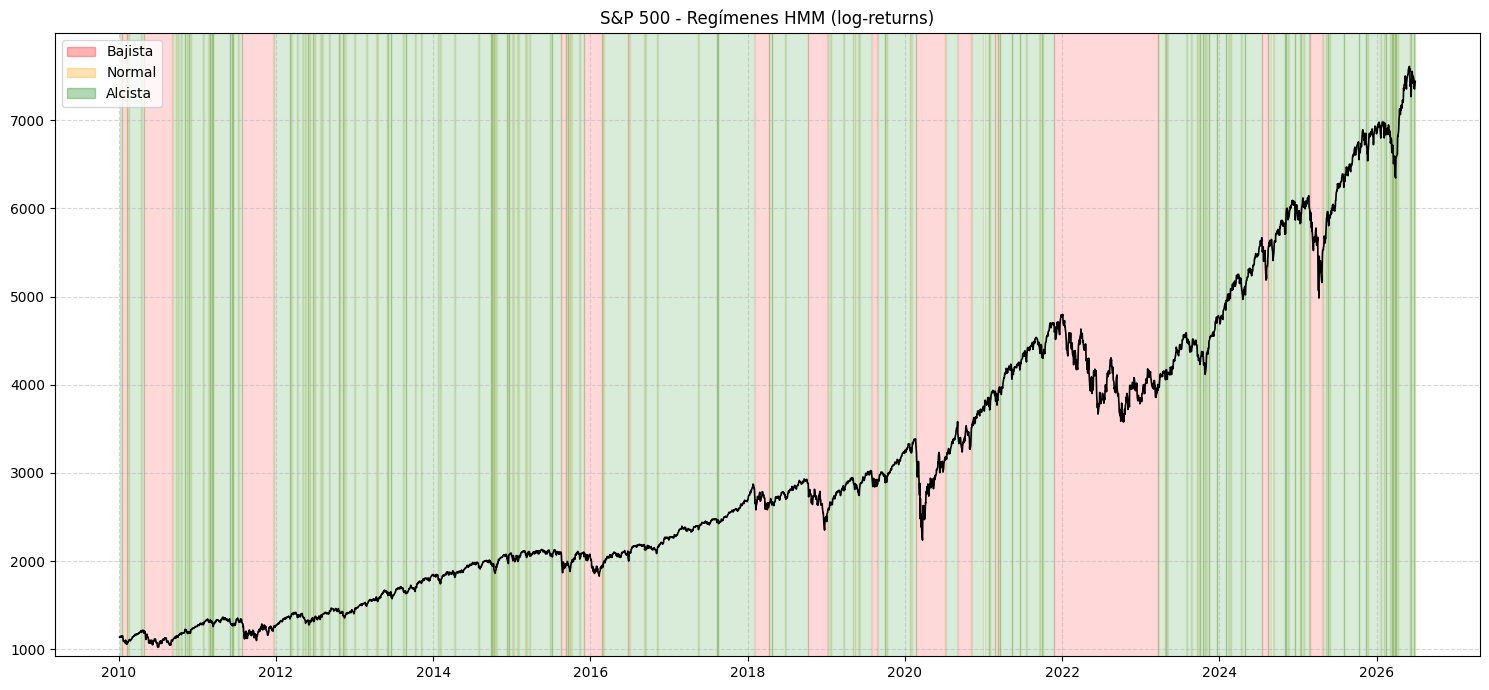

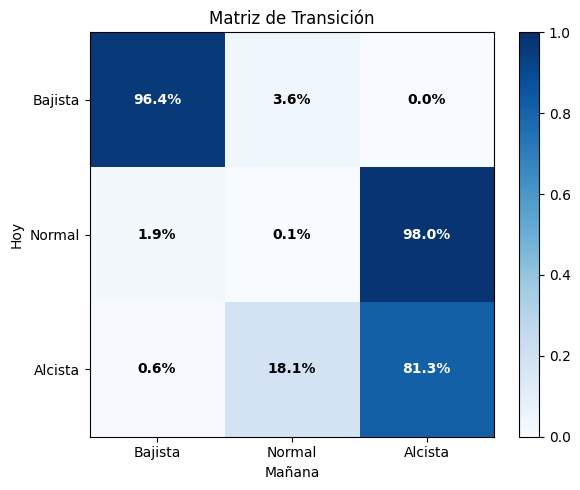

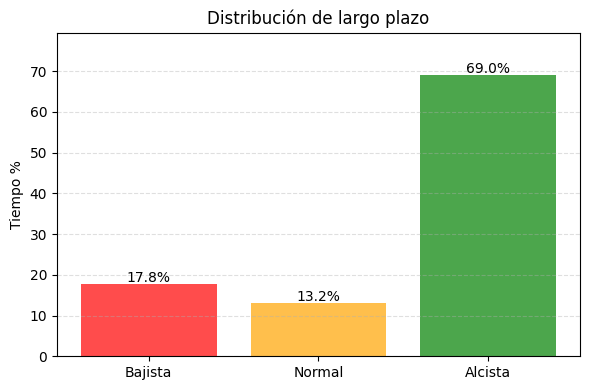

In [96]:
import yfinance as yf
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==============================
# CONFIGURACIÓN
# ==============================
TICKER = "^GSPC"
START = "2010-01-01"
END = "2026-12-31"
N_STATES = 3
ESTADOS = ["Bajista", "Normal", "Alcista"]
COLORES = {0: "red", 1: "orange", 2: "green"}

# ==============================
# 1. DATOS
# ==============================
def descargar_datos():
    df = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df["Returns"] = np.log(df["Close"] / df["Close"].shift(1))
    return df.dropna()

data = descargar_datos()

# ==============================
# 2. MODELO HMM
# ==============================
X = data[["Returns"]].values
hmm = GaussianHMM(n_components=N_STATES, covariance_type="full",
                 n_iter=1000, random_state=42)
hmm.fit(X)

# ordenar estados por media (bajista → alcista)
order = np.argsort(hmm.means_.flatten())
data["State"] = pd.Series(hmm.predict(X), index=data.index).map(
    {o: n for n, o in enumerate(order)}
).astype(int) 

# parámetros ordenados
transmat = hmm.transmat_[order][:, order]
means_log = hmm.means_[order].flatten()
std_log = np.sqrt(hmm.covars_[order].reshape(N_STATES, -1)[:, 0])

# ==============================
# 3. RESUMEN HOY
# ==============================
data = data.dropna(subset=["State", "Close", "Returns"])
precio_hoy = float(data["Close"].iloc[-1])
ret_hoy = float(data["Returns"].iloc[-1] * 100)
estado_hoy = int(data["State"].iloc[-1])
fecha_hoy = data.index[-1].date()

df_params = pd.DataFrame({
    "Media diaria log": means_log,
    "Media diaria %": np.expm1(means_log) * 100,
    "Vol anual %": std_log * np.sqrt(252) * 100,
}, index=ESTADOS)

print(f"--- {fecha_hoy} ---")
print(f"Precio S&P500: {precio_hoy:.2f} ({ret_hoy:+.2f}% log)")
print(f"Régimen actual: {ESTADOS[estado_hoy]}")
print("\nParámetros por régimen:")
print(df_params.round(3))

# ==============================
# 4. PRONÓSTICO
# ==============================
prob_manana = transmat[estado_hoy]
prob_2d = prob_manana @ transmat

print("\n--- Matriz de Transición ---")
print(pd.DataFrame(transmat, index=ESTADOS, columns=ESTADOS).round(3))

print(f"\nMañana → {ESTADOS[prob_manana.argmax()]} ({prob_manana.max():.1%})")
for i, p in enumerate(prob_manana):
    print(f" {ESTADOS[i]:8s}: {p:.1%}")

print("\nEn 2 días:")
for i, p in enumerate(prob_2d):
    print(f" {ESTADOS[i]:8s}: {p:.1%}")

# ==============================
# 5. DISTRIBUCIÓN ESTACIONARIA
# ==============================
eigvals, eigvecs = np.linalg.eig(transmat.T)
pi = np.real(eigvecs[:, np.isclose(eigvals, 1)]).flatten()
pi /= pi.sum()

print("\n--- Estacionaria (largo plazo) ---")
for name, p in zip(ESTADOS, pi):
    print(f" {name:8s}: {p:.1%}")

# ==============================
# 6. GRÁFICOS
# ==============================
# 6a. Precio con regímenes
plt.figure(figsize=(15, 7))
close = data["Close"].to_numpy()
plt.plot(data.index, close, "k", lw=1.2, label="S&P 500")

for i in range(N_STATES):
    mask = data["State"].values == i
    plt.fill_between(data.index, 0, close.max()*1.1, where=mask,
                     color=COLORES[i], alpha=0.15)

handles = [mpatches.Patch(color=COLORES[i], alpha=0.3, label=ESTADOS[i])
           for i in range(N_STATES)]
plt.legend(handles=handles, loc="upper left") # <- aquí está el fix

plt.title("S&P 500 - Regímenes HMM (log-returns)")
plt.ylim(close.min()*0.9, close.max()*1.05)
plt.grid(ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 6b. Heatmap transición
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(transmat, cmap="Blues", vmin=0, vmax=1)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{transmat[i,j]:.1%}", ha="center", va="center",
                color="white" if transmat[i,j] > 0.5 else "black", fontweight="bold")
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(ESTADOS); ax.set_yticklabels(ESTADOS)
ax.set_xlabel("Mañana"); ax.set_ylabel("Hoy")
ax.set_title("Matriz de Transición")
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

# 6c. Barras estacionaria
plt.figure(figsize=(6, 4))
bars = plt.bar(ESTADOS, pi*100, color=[COLORES[i] for i in range(3)], alpha=0.7)
plt.ylabel("Tiempo %"); plt.title("Distribución de largo plazo")
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
             f"{b.get_height():.1f}%", ha="center")
plt.ylim(0, max(pi*100)*1.15)
plt.grid(axis="y", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Mejor número de estados: 6
--- Análisis al 29 de Junio de 2026 ---
Precio SP500: 7440.43
Variación vs ayer: 1.18%
Régimen actual: Muy Alcista
Estado más probable mañana: Muy Alcista (prob 0.94)

MATRIZ DE TRANSICIÓN (estado actual → estado futuro)
                   Extremo (mañana)  Muy Alcista (mañana)  Neutral (mañana)  \
Extremo (hoy)                0.9715                0.0000            0.0000   
Muy Alcista (hoy)            0.0000                0.9375            0.0421   
Neutral (hoy)                0.0000                0.0336            0.9267   
Bajista (hoy)                0.0277                0.0017            0.0508   
Muy Bajista (hoy)            0.0000                0.0000            0.0000   
Alcista (hoy)                0.0000                0.0329            0.0000   

                   Bajista (mañana)  Muy Bajista (mañana)  Alcista (mañana)  
Extremo (hoy)                0.0285                0.0000            0.0000  
Muy Alcista (hoy)            0.0000       

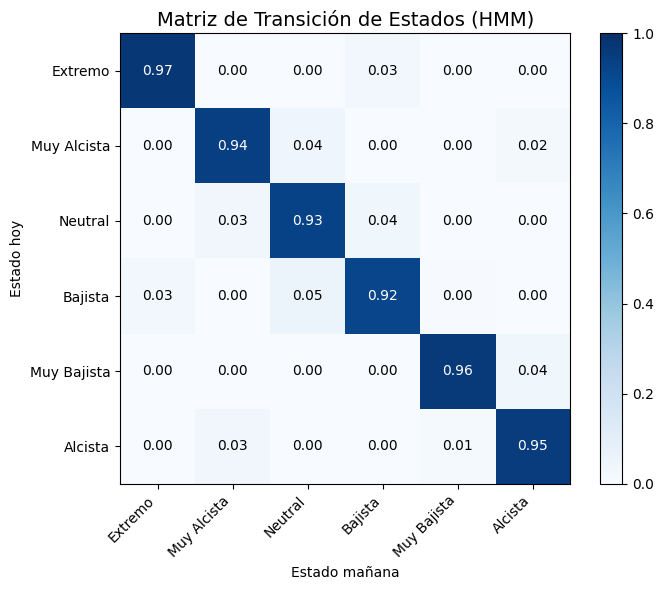

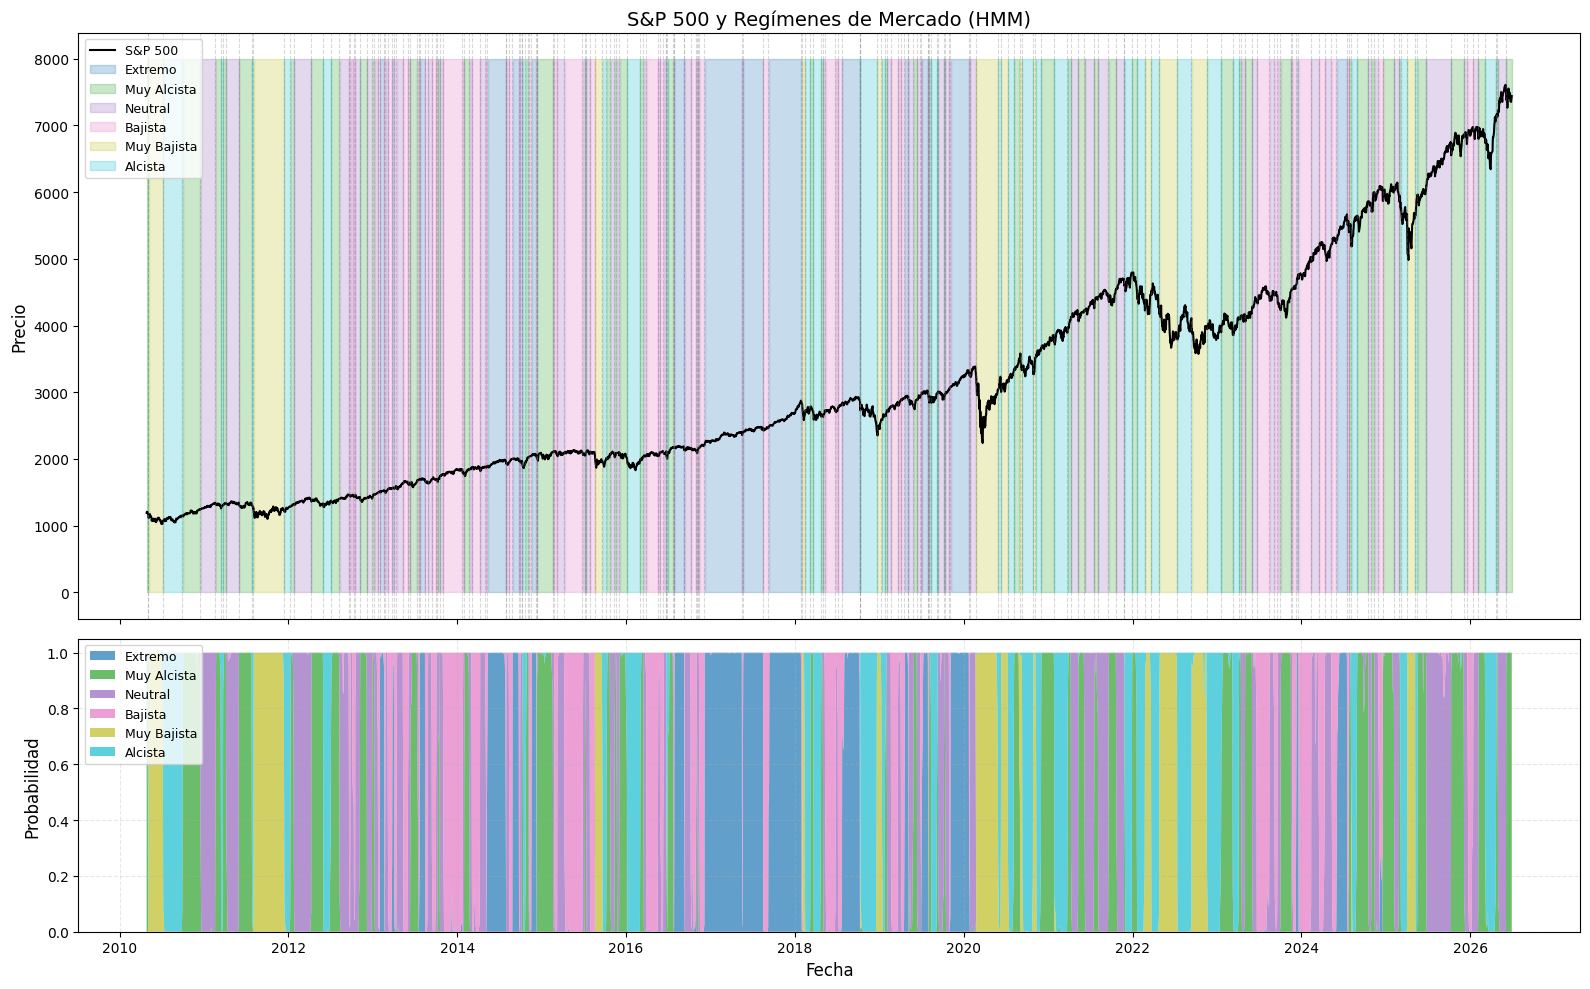

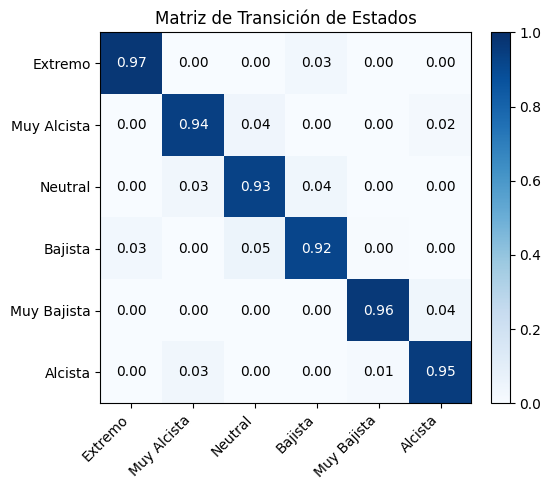

In [81]:
import yfinance as yf
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ============================
# 1. Descarga y preparación (con LOG-RETURNS)
# ============================
ticker = "^GSPC"
raw = yf.download(ticker, start="2010-01-01", end="2026-06-30", auto_adjust=True)
data = pd.DataFrame(index=raw.index)
data['Close'] = raw['Close']

# --- CAMBIO PRINCIPAL: Log-Returns ---
data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))  # <- NUEVO

# Features adicionales (funcionan igual)
data['vol20'] = data['Returns'].rolling(20).std()
data['vol_ratio'] = data['vol20'] / data['vol20'].rolling(60).std()
data['ret_cum5'] = data['Returns'].rolling(5).sum()  # Ahora es exactamente el retorno de 5 días

# VIX (con shift)
vix_raw = yf.download('^VIX', start="2010-01-01", end="2026-06-30", auto_adjust=True)
data['vix'] = vix_raw['Close'].shift(1)

data.dropna(inplace=True)

features = ['Returns', 'vol20', 'ret_cum5', 'vix']
X_raw = data[features].values

# Estandarizar (opcional pero recomendado)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# ============================
# 2. Selección del número de estados (BIC)
# ============================
n_range = range(2, 7)
bics = []
for n in n_range:
    model = GaussianHMM(n_components=n, covariance_type='full', n_iter=1000, random_state=42)
    model.fit(X)
    bics.append(model.bic(X))
best_n = n_range[np.argmin(bics)]
print(f"Mejor número de estados: {best_n}")

# ============================
# 3. Ajuste final (mejor de varias semillas)
# ============================
best_model = None
best_score = -np.inf
for seed in [42, 123, 456, 789]:
    model = GaussianHMM(n_components=best_n, covariance_type='full', n_iter=1000, random_state=seed)
    model.fit(X)
    if model.score(X) > best_score:
        best_score = model.score(X)
        best_model = model
model = best_model

hidden_states = model.predict(X)
data['State'] = hidden_states

# ============================
# 4. Etiquetado automático de estados
# ============================
state_means = model.means_[:, 0]  # media del retorno
order = np.argsort(state_means)
n_states = best_n

if n_states == 2:
    labels_map = {order[0]: 'Bajista', order[1]: 'Alcista'}
elif n_states == 3:
    labels_map = {order[0]: 'Bajista', order[1]: 'Normal', order[2]: 'Alcista'}
elif n_states == 4:
    labels_map = {order[0]: 'Muy Bajista', order[1]: 'Bajista', 
                  order[2]: 'Alcista', order[3]: 'Muy Alcista'}
else:
    labels = ['Muy Bajista', 'Bajista', 'Neutral', 'Alcista', 'Muy Alcista', 'Extremo']
    labels_map = {order[i]: labels[i] for i in range(n_states)}

state_names = [labels_map[i] for i in range(n_states)]

# ============================
# 5. Resultados e interpretación (CORREGIDO)
# ============================
estado_hoy = int(data['State'].iloc[-1])
regimen_actual = state_names[estado_hoy]

precio_hoy = float(data['Close'].iloc[-1])
precio_ayer = float(data['Close'].iloc[-2])
variacion = (precio_hoy / precio_ayer - 1) * 100

print(f"--- Análisis al {data.index[-1].strftime('%d de %B de %Y')} ---")
print(f"Precio SP500: {precio_hoy:.2f}")
print(f"Variación vs ayer: {variacion:.2f}%")
print(f"Régimen actual: {regimen_actual}")

# Predicción del estado de mañana
last_state = hidden_states[-1]
trans_probs = model.transmat_[last_state]
next_state = np.argmax(trans_probs)
prob_next = trans_probs[next_state]
print(f"Estado más probable mañana: {state_names[next_state]} (prob {prob_next:.2f})")

# ============================
# 6. NUEVO: Matriz de transición completa y probabilidades esperadas
# ============================
print("\n" + "="*60)
print("MATRIZ DE TRANSICIÓN (estado actual → estado futuro)")
print("="*60)
# Crear DataFrame para visualizar la matriz con nombres
trans_df = pd.DataFrame(model.transmat_, 
                        index=[f"{s} (hoy)" for s in state_names],
                        columns=[f"{s} (mañana)" for s in state_names])
print(trans_df.round(4))
print("\n")

# Probabilidades para mañana dado el estado actual (última fila)
print("Probabilidades para mañana (dado el estado actual):")
for i, prob in enumerate(trans_probs):
    print(f"  → {state_names[i]}: {prob:.4f} ({prob*100:.2f}%)")

# Distribución estacionaria (probabilidad a largo plazo de cada estado)
# Se calcula como el autovector izquierdo de la matriz de transición (valores propios = 1)
# Resolver π = π · P  con suma π = 1
eigenvals, eigenvects = np.linalg.eig(model.transmat_.T)
stationary = eigenvects[:, np.isclose(eigenvals, 1.0)].flatten().real
stationary = stationary / stationary.sum()  # normalizar
stationary = stationary.clip(0, 1)  # evitar valores negativos por redondeo
print("\nDistribución estacionaria (probabilidad esperada a largo plazo):")
for i, prob in enumerate(stationary):
    print(f"  → {state_names[i]}: {prob:.4f} ({prob*100:.2f}%)")

# ============================
# 7. Visualización: Heatmap de la matriz de transición
# ============================
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(model.transmat_, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n_states))
ax.set_yticks(range(n_states))
ax.set_xticklabels(state_names, rotation=45, ha='right')
ax.set_yticklabels(state_names)
ax.set_title('Matriz de Transición de Estados (HMM)', fontsize=14)
ax.set_xlabel('Estado mañana')
ax.set_ylabel('Estado hoy')

# Añadir valores dentro del heatmap
for i in range(n_states):
    for j in range(n_states):
        ax.text(j, i, f"{model.transmat_[i, j]:.2f}", 
                ha='center', va='center', 
                color='black' if model.transmat_[i, j] < 0.5 else 'white')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ============================
# 8. Visualización de precios y regímenes (opcional)
# ============================
# (Puedes añadir aquí el gráfico de precio con regiones coloreadas)
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba

# Colores para cada estado (puedes personalizar)
palette = plt.cm.tab10(np.linspace(0, 1, n_states))
colores = {i: palette[i] for i in range(n_states)}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, 
                                gridspec_kw={'height_ratios': [2, 1]})

# Panel 1: Precio + regiones con transparencia según probabilidad posterior
posterior = model.predict_proba(X)  # probabilidades suavizadas

ax1.plot(data.index, data['Close'], color='black', linewidth=1.5, label='S&P 500')
for i in range(n_states):
    # Zonas donde la probabilidad del estado i es > 0.5 (o usa umbral variable)
    mask = posterior[:, i] > 0.5
    ax1.fill_between(data.index, 0, data['Close'].max()*1.05, 
                     where=mask, color=colores[i], alpha=0.25, label=state_names[i])
# Líneas verticales en cambios de estado (opcional)
changes = np.where(np.diff(hidden_states) != 0)[0]
for c in changes:
    ax1.axvline(data.index[c], color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

ax1.set_ylabel('Precio', fontsize=12)
ax1.set_title('S&P 500 y Regímenes de Mercado (HMM)', fontsize=14)
ax1.legend(loc='upper left', fontsize=9)

# Panel 2: Probabilidades suavizadas (stackplot)
ax2.stackplot(data.index, posterior.T, colors=[colores[i] for i in range(n_states)], 
              alpha=0.7, labels=state_names)
ax2.set_ylabel('Probabilidad', fontsize=12)
ax2.set_xlabel('Fecha', fontsize=12)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================
# 9. Matriz de transición (mapa de calor)
# ============================
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(model.transmat_, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n_states))
ax.set_yticks(range(n_states))
ax.set_xticklabels(state_names, rotation=45, ha='right')
ax.set_yticklabels(state_names)
ax.set_title('Matriz de Transición de Estados')
for i in range(n_states):
    for j in range(n_states):
        ax.text(j, i, f"{model.transmat_[i, j]:.2f}", 
                ha='center', va='center', color='black' if model.transmat_[i,j] < 0.5 else 'white')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

📥 Descargando datos...
   Rango: 2010-04-28 → 2026-06-29
   Observaciones: 4067

🔍 Seleccionando número óptimo de estados (BIC)...
   Mejor número de estados: 6

⚙️  Ajustando modelo final (múltiples semillas)...

📊  ANÁLISIS AL 29 de Junio de 2026
Precio S&P 500: 7440.43
Variación vs ayer: +1.18%
Régimen actual: Muy Alcista

📈  Retorno log esperado por estado (diario):
        Extremo: 0.000948  (anualizado: +0.239)
    Muy Alcista: 0.000756  (anualizado: +0.190)
        Neutral: 0.000645  (anualizado: +0.163)
        Bajista: 0.000144  (anualizado: +0.036)
    Muy Bajista: -0.001117  (anualizado: -0.281)
        Alcista: 0.000645  (anualizado: +0.163)

🔮  Estado más probable mañana: Muy Alcista (prob 0.94)

📐  Log‑verosimilitud: -10004.12
📐  BIC: 20997.20

MATRIZ DE TRANSICIÓN (ordenada de Bajista a Alcista)
                   Muy Bajista (mañana)  Bajista (mañana)  Neutral (mañana)  \
Muy Bajista (hoy)                0.9645            0.0000            0.0000   
Bajista (hoy)       

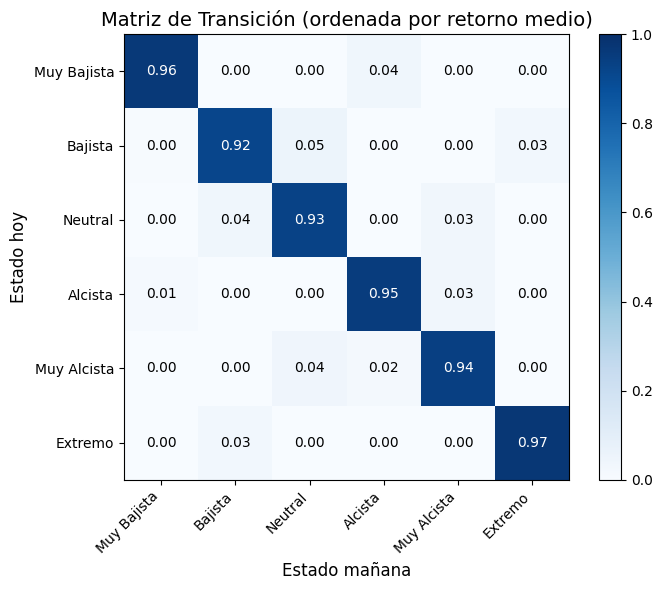


📊  Generando gráfico de precio y probabilidades...


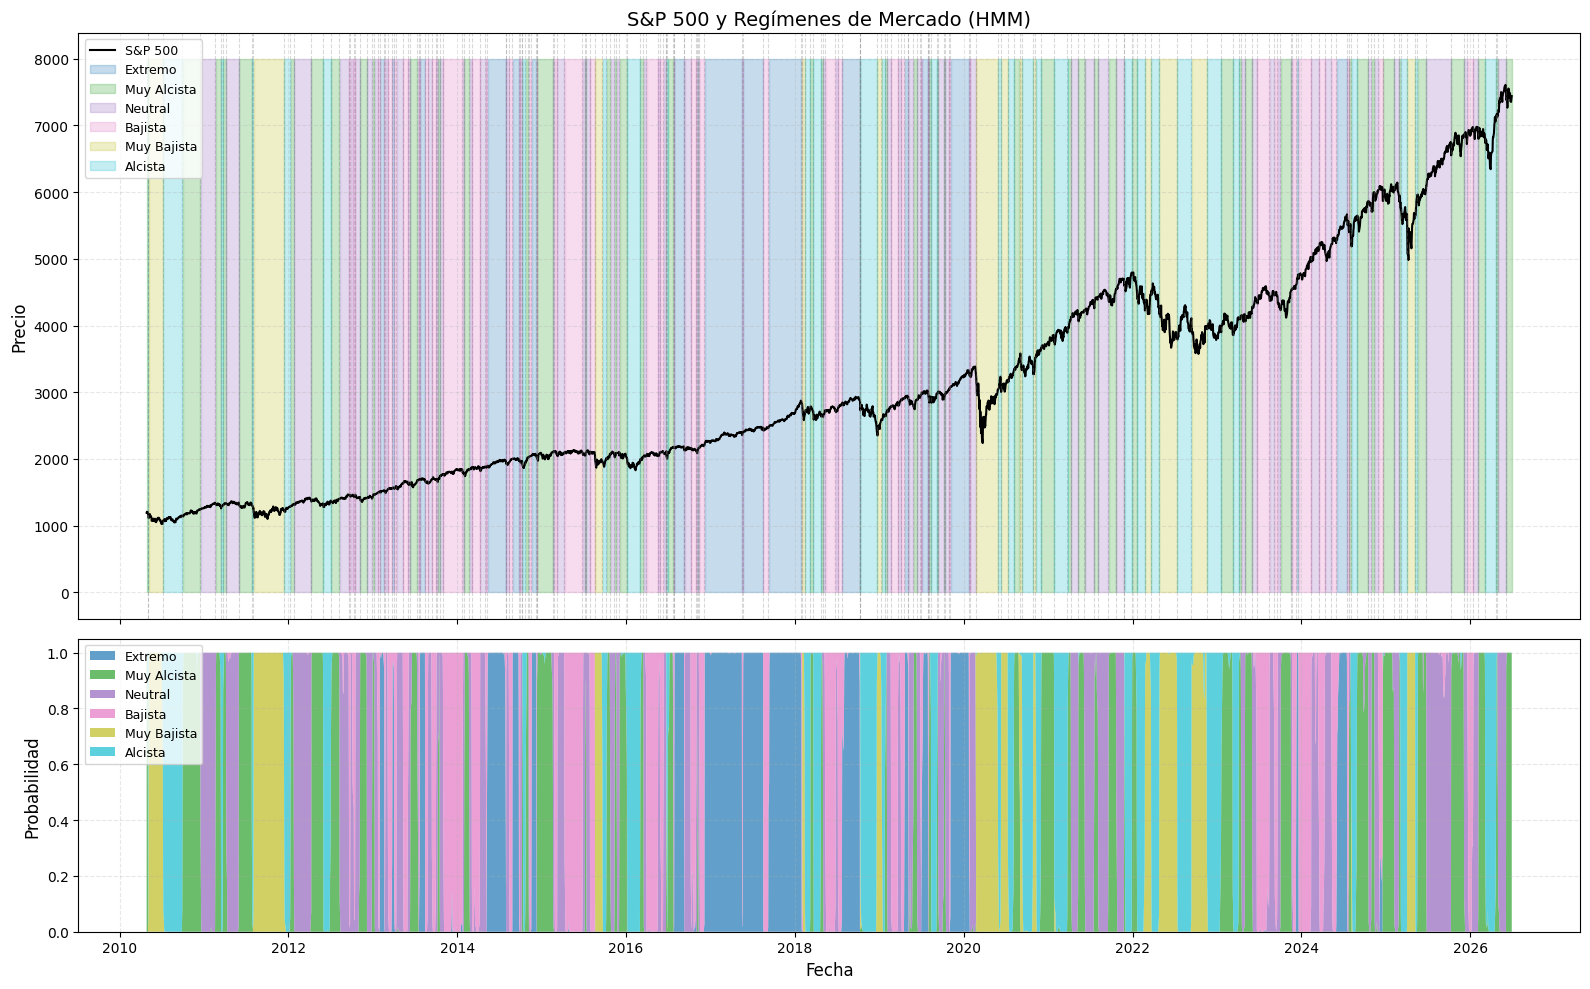


💾  Archivos CSV guardados:
   → sp500_estados_hmm.csv
   → matriz_transicion_hmm.csv

✅  Análisis completado con éxito.


In [97]:
import yfinance as yf
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import to_rgba
import warnings
warnings.filterwarnings('ignore')

# ======================================================================
# 1. DESCARGA Y PREPARACIÓN (con LOG‑RETURNS y fecha dinámica)
# ======================================================================

print("📥 Descargando datos...")

ticker = "^GSPC"
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

raw = yf.download(ticker, start="2010-01-01", end=end_date, auto_adjust=True, progress=False)
data = pd.DataFrame(index=raw.index)
data['Close'] = raw['Close']

# Log‑returns (mejor para HMM Gaussiano)
data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))

# Features adicionales (volatilidad, momentum, VIX)
data['vol20'] = data['Returns'].rolling(20).std()
data['vol_ratio'] = data['vol20'] / data['vol20'].rolling(60).std()
data['ret_cum5'] = data['Returns'].rolling(5).sum()

# VIX (shift 1 para evitar look‑ahead)
vix_raw = yf.download('^VIX', start="2010-01-01", end=end_date, auto_adjust=True, progress=False)
data['vix'] = vix_raw['Close'].shift(1)

# Eliminar filas con NaN
data.dropna(inplace=True)

# Features que alimentarán el modelo
features = ['Returns', 'vol20', 'ret_cum5', 'vix']
X_raw = data[features].values

# Estandarización (fundamental para HMM con Gaussian)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"   Rango: {data.index[0].date()} → {data.index[-1].date()}")
print(f"   Observaciones: {len(data)}")

# ======================================================================
# 2. SELECCIÓN DEL NÚMERO DE ESTADOS (BIC)
# ======================================================================

print("\n🔍 Seleccionando número óptimo de estados (BIC)...")

n_range = range(2, 7)
bics = []
for n in n_range:
    model = GaussianHMM(n_components=n, covariance_type='full', n_iter=1000, random_state=42)
    model.fit(X)
    bics.append(model.bic(X))
best_n = n_range[np.argmin(bics)]
print(f"   Mejor número de estados: {best_n}")

# ======================================================================
# 3. AJUSTE FINAL (mejor de varias semillas)
# ======================================================================

print("\n⚙️  Ajustando modelo final (múltiples semillas)...")

best_model = None
best_score = -np.inf
for seed in [42, 123, 456, 789]:
    model = GaussianHMM(n_components=best_n, covariance_type='full', n_iter=1000, random_state=seed)
    model.fit(X)
    if model.score(X) > best_score:
        best_score = model.score(X)
        best_model = model
model = best_model

hidden_states = model.predict(X)
data['State'] = hidden_states

# ======================================================================
# 4. ETIQUETADO AUTOMÁTICO (usando medias en escala original)
# ======================================================================

# Recuperar media y desviación de 'Returns' en escala original
ret_mean_orig = scaler.mean_[0]
ret_std_orig  = scaler.scale_[0]
state_means_orig = model.means_[:, 0] * ret_std_orig + ret_mean_orig
order = np.argsort(state_means_orig)   # de menor a mayor retorno

n_states = best_n

# Asignar nombres según el número de estados
if n_states == 2:
    labels_map = {order[0]: 'Bajista', order[1]: 'Alcista'}
elif n_states == 3:
    labels_map = {order[0]: 'Bajista', order[1]: 'Normal', order[2]: 'Alcista'}
elif n_states == 4:
    labels_map = {order[0]: 'Muy Bajista', order[1]: 'Bajista',
                  order[2]: 'Alcista', order[3]: 'Muy Alcista'}
else:
    labels = ['Muy Bajista', 'Bajista', 'Neutral', 'Alcista', 'Muy Alcista', 'Extremo']
    labels_map = {order[i]: labels[i] for i in range(n_states)}

# Lista de nombres ordenados por retorno medio (bajista → alcista)
state_names = [labels_map[i] for i in range(n_states)]
sorted_idx = np.argsort(state_means_orig)   # índices para ordenar matriz
sorted_names = [state_names[i] for i in sorted_idx]

# ======================================================================
# 5. RESULTADOS E INTERPRETACIÓN
# ======================================================================

estado_hoy = int(data['State'].iloc[-1])
regimen_actual = state_names[estado_hoy]

precio_hoy = float(data['Close'].iloc[-1])
precio_ayer = float(data['Close'].iloc[-2])
variacion = (precio_hoy / precio_ayer - 1) * 100

print("\n" + "="*60)
print(f"📊  ANÁLISIS AL {data.index[-1].strftime('%d de %B de %Y')}")
print("="*60)
print(f"Precio S&P 500: {precio_hoy:.2f}")
print(f"Variación vs ayer: {variacion:+.2f}%")
print(f"Régimen actual: {regimen_actual}")

# Retorno log esperado por estado (diario y anualizado)
print("\n📈  Retorno log esperado por estado (diario):")
for i, name in enumerate(state_names):
    ann = state_means_orig[i] * 252
    print(f"   {name:>12s}: {state_means_orig[i]:.6f}  (anualizado: {ann:+.3f})")

# Predicción del estado de mañana
last_state = hidden_states[-1]
trans_probs = model.transmat_[last_state]
next_state = np.argmax(trans_probs)
prob_next = trans_probs[next_state]
print(f"\n🔮  Estado más probable mañana: {state_names[next_state]} (prob {prob_next:.2f})")

print(f"\n📐  Log‑verosimilitud: {model.score(X):.2f}")
print(f"📐  BIC: {model.bic(X):.2f}")

# ======================================================================
# 6. MATRIZ DE TRANSICIÓN (ordenada por retorno medio)
# ======================================================================

# Reordenar filas y columnas según sorted_idx
trans_ordered = model.transmat_[sorted_idx][:, sorted_idx]

print("\n" + "="*60)
print("MATRIZ DE TRANSICIÓN (ordenada de Bajista a Alcista)")
print("="*60)
trans_df = pd.DataFrame(trans_ordered,
                        index=[f"{s} (hoy)" for s in sorted_names],
                        columns=[f"{s} (mañana)" for s in sorted_names])
print(trans_df.round(4))

# Probabilidades para mañana dado el estado actual (reordenadas)
print("\nProbabilidades para mañana (desde el estado actual):")
for i, name in enumerate(sorted_names):
    prob = trans_ordered[sorted_idx.tolist().index(last_state), i]
    print(f"   → {name:>12s}: {prob:.4f} ({prob*100:.2f}%)")

# Distribución estacionaria (reordenada)
eigenvals, eigenvects = np.linalg.eig(model.transmat_.T)
stationary = eigenvects[:, np.isclose(eigenvals, 1.0)].flatten().real
stationary = stationary / stationary.sum()
stationary = stationary.clip(0, 1)
stationary_ordered = stationary[sorted_idx]

print("\n📊  Distribución estacionaria (probabilidad a largo plazo):")
for i, name in enumerate(sorted_names):
    print(f"   → {name:>12s}: {stationary_ordered[i]:.4f} ({stationary_ordered[i]*100:.2f}%)")

# ======================================================================
# 7. HEATMAP DE LA MATRIZ DE TRANSICIÓN (ordenado)
# ======================================================================

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(trans_ordered, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n_states))
ax.set_yticks(range(n_states))
ax.set_xticklabels(sorted_names, rotation=45, ha='right')
ax.set_yticklabels(sorted_names)
ax.set_title('Matriz de Transición (ordenada por retorno medio)', fontsize=14)
ax.set_xlabel('Estado mañana', fontsize=12)
ax.set_ylabel('Estado hoy', fontsize=12)

for i in range(n_states):
    for j in range(n_states):
        ax.text(j, i, f"{trans_ordered[i, j]:.2f}",
                ha='center', va='center',
                color='black' if trans_ordered[i, j] < 0.5 else 'white')

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ======================================================================
# 8. VISUALIZACIÓN: PRECIO + PROBABILIDADES SUAVIZADAS
# ======================================================================

print("\n📊  Generando gráfico de precio y probabilidades...")

palette = plt.cm.tab10(np.linspace(0, 1, n_states))
colores = {i: palette[i] for i in range(n_states)}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# Panel 1: Precio + regiones coloreadas por estado (umbral 0.5)
posterior = model.predict_proba(X)  # probabilidades suavizadas

ax1.plot(data.index, data['Close'], color='black', linewidth=1.5, label='S&P 500')
for i in range(n_states):
    mask = posterior[:, i] > 0.5
    ax1.fill_between(data.index, 0, data['Close'].max() * 1.05,
                     where=mask, color=colores[i], alpha=0.25, label=state_names[i])

# Líneas verticales en cambios de estado
changes = np.where(np.diff(hidden_states) != 0)[0]
for c in changes:
    ax1.axvline(data.index[c], color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

ax1.set_ylabel('Precio', fontsize=12)
ax1.set_title('S&P 500 y Regímenes de Mercado (HMM)', fontsize=14)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.3)

# Panel 2: Probabilidades suavizadas (stackplot)
ax2.stackplot(data.index, posterior.T,
              colors=[colores[i] for i in range(n_states)],
              alpha=0.7, labels=state_names)
ax2.set_ylabel('Probabilidad', fontsize=12)
ax2.set_xlabel('Fecha', fontsize=12)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# ======================================================================
# 9. EXPORTACIÓN A CSV
# ======================================================================

# Guardar datos principales con estados y probabilidades
data_out = data[['Close', 'Returns', 'State']].copy()
data_out['Prob_Bajista'] = posterior[:, sorted_idx.tolist().index(0)] if 0 in sorted_idx else np.nan
data_out['Prob_Normal'] = posterior[:, sorted_idx.tolist().index(1)] if 1 in sorted_idx else np.nan
data_out['Prob_Alcista'] = posterior[:, sorted_idx.tolist().index(2)] if 2 in sorted_idx else np.nan
data_out.to_csv("sp500_estados_hmm.csv")

# Guardar matriz de transición ordenada
trans_df.to_csv("matriz_transicion_hmm.csv")

print("\n💾  Archivos CSV guardados:")
print("   → sp500_estados_hmm.csv")
print("   → matriz_transicion_hmm.csv")

print("\n✅  Análisis completado con éxito.")

📥 Descargando datos...
   Rango: 2010-04-28 → 2026-06-30
   Observaciones: 4068

🔁 Ejecutando backtest walk‑forward...


Model is not converging.  Current: -2273.733016386546 is not greater than -2273.7328633841194. Delta is -0.00015300242648663698
Model is not converging.  Current: -2696.5999409201504 is not greater than -2696.4274958832193. Delta is -0.17244503693109436
Model is not converging.  Current: -2853.487198583011 is not greater than -2853.3566092129063. Delta is -0.13058937010464433
Model is not converging.  Current: -2584.8746324220556 is not greater than -2584.8710411880816. Delta is -0.0035912339740207244
Model is not converging.  Current: -3087.8991367835747 is not greater than -3087.154649107634. Delta is -0.7444876759404906
Model is not converging.  Current: -3298.058666081718 is not greater than -3298.0554370000623. Delta is -0.0032290816557178914
Model is not converging.  Current: -3364.9857767499984 is not greater than -3364.8002942489984. Delta is -0.18548250100002406
Model is not converging.  Current: -3462.0223408915913 is not greater than -3461.4757474248704. Delta is -0.54659346


📊 Resultados del backtest:
Entropía media de la previsión: 0.2203
Probabilidades medias pronosticadas por estado:
   Estado 0: 0.379
   Estado 1: 0.377
   Estado 2: 0.243


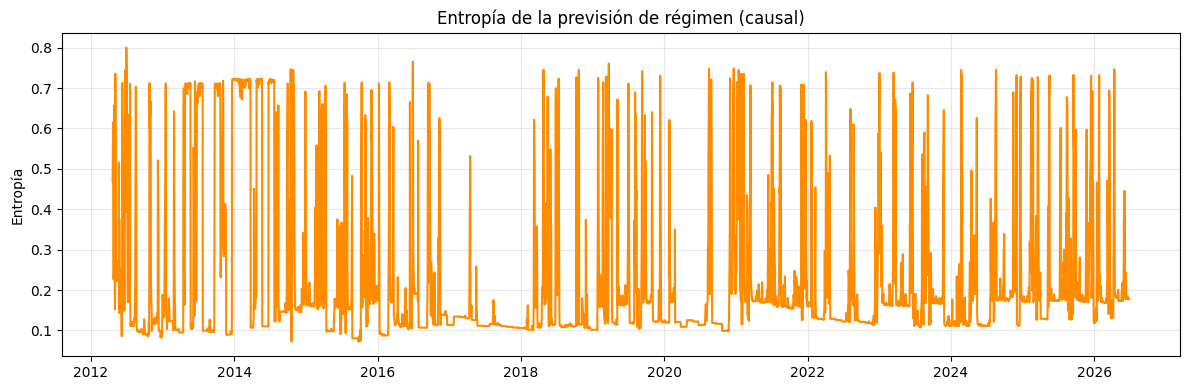


🚀 Modo producción: entrenando con todos los datos hasta ayer...

Fecha del último dato de entrenamiento: 2026-06-29
Previsión para la próxima sesión:
   Estado 0: probabilidad = 0.0198
   Estado 1: probabilidad = 0.9662
   Estado 2: probabilidad = 0.0140

Entropía de la previsión: 0.1705 (0 = certeza, >0.7 = alta incertidumbre)
Régimen más probable al cierre de ayer: Estado 1

Modelo guardado como 'hmm_production.pkl'.


In [98]:
"""
HMM con predicción causal (forward filtering) y walk‑forward estricto.
Resuelve leaks de información futura, estabiliza la matriz de transición y
evalúa capacidad predictiva real.

Flujo:
  - BACKTEST: simula el proceso día a día, reentrenando periódicamente.
  - LIVE: entrena con todos los datos hasta ayer y pronostica mañana.
"""

import yfinance as yf
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
import warnings
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')

# =============================================================================
# 0. CONFIGURACIÓN
# =============================================================================
TICKER_SPX = "^GSPC"
TICKER_VIX = "^VIX"
START_DATE = "2010-01-01"
# Número de estados (fijo; en producción conviene seleccionar vía BIC en cada
# reentreno, pero aquí simplificamos a 3)
N_STATES = 3
# Periodicidad de reentreno (en días hábiles, aprox 21 = mensual)
REFIT_EVERY = 21
# Ventana mínima de entrenamiento inicial (días hábiles)
MIN_TRAIN_WINDOW = 500
# Features a usar
FEATURES = ['Returns', 'vol20', 'ret_cum5', 'vix']
# Sticky prior: peso extra para autotransiciones (alto -> más persistencia)
STICKY_WEIGHT = 50.0   # <-- ajustable

# =============================================================================
# 1. DESCARGA Y PREPARACIÓN DE DATOS (SIN LOOK‑AHEAD)
# =============================================================================
print("📥 Descargando datos...")

end_date = (datetime.today() + timedelta(days=1)).strftime('%Y-%m-%d')  # por si hoy no hay sesión
raw_spx = yf.download(TICKER_SPX, start=START_DATE, end=end_date, auto_adjust=True, progress=False)
raw_vix = yf.download(TICKER_VIX, start=START_DATE, end=end_date, auto_adjust=True, progress=False)

# Defensivo contra MultiIndex de yfinance
if isinstance(raw_spx.columns, pd.MultiIndex):
    raw_spx.columns = raw_spx.columns.get_level_values(0)
if isinstance(raw_vix.columns, pd.MultiIndex):
    raw_vix.columns = raw_vix.columns.get_level_values(0)

data = pd.DataFrame(index=raw_spx.index)
data['Close'] = raw_spx['Close']

# Log‑returns
data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))

# Features que no miran al futuro
data['vol20'] = data['Returns'].rolling(20).std()
data['vol_ratio'] = data['vol20'] / data['vol20'].rolling(60).std()
data['ret_cum5'] = data['Returns'].rolling(5).sum()

# VIX: usamos cierre del día ANTERIOR (shift(1)) y alineamos índices explícitamente
vix_series = raw_vix['Close'].shift(1).reindex(data.index, method='ffill')
data['vix'] = vix_series

# Eliminar filas con NaN
data.dropna(inplace=True)

print(f"   Rango: {data.index[0].date()} → {data.index[-1].date()}")
print(f"   Observaciones: {len(data)}")

# =============================================================================
# 2. FUNCIONES AUXILIARES (CAUSALES)
# =============================================================================

def filtered_probabilities(model, X):
    """
    Calcula las probabilidades filtradas α_t = P(S_t | y_1..y_t)
    (forward pass sin backward).
    """
    n_states = model.n_components
    T = len(X)
    log_B = np.zeros((T, n_states))
    for i in range(n_states):
        log_B[:, i] = multivariate_normal.logpdf(
            X, mean=model.means_[i], cov=model.covars_[i]
        )
    alpha = np.zeros((T, n_states))
    # init
    alpha[0] = model.startprob_ * np.exp(log_B[0] - log_B[0].max())
    alpha[0] /= alpha[0].sum()
    # recursion
    for t in range(1, T):
        pred = alpha[t-1] @ model.transmat_            # predicción de un paso
        unnorm = pred * np.exp(log_B[t] - log_B[t].max())
        alpha[t] = unnorm / unnorm.sum()
    return alpha   # alpha[t] = P(S_t | y_1..y_t)


def entropy(probs):
    """Entropía de una distribución de probabilidad."""
    p = np.array(probs, dtype=float)
    p = p[p > 0]  # evitar log(0)
    return -np.sum(p * np.log(p))


# =============================================================================
# 3. CLASE WRAPPER CON STICKY PRIOR Y FILTRADO CAUSAL
# =============================================================================

class StickyFilteredHMM:
    """
    GaussianHMM con prior Dirichlet en la matriz de transición (sticky)
    y acceso a probabilidades filtradas (forward‑only).
    """
    def __init__(self, n_components, sticky_weight=50.0, covariance_type='full',
                 n_iter=1000, random_state=42):
        self.n_components = n_components
        self.sticky_weight = sticky_weight
        self.covariance_type = covariance_type
        self.n_iter = n_iter
        self.random_state = random_state
        self.model = None
        self.alpha_ = None          # probabilidades filtradas tras fit()
        self.scaler = StandardScaler()

    def fit(self, X_raw):
        """Ajusta scaler y HMM (solo con datos de entrenamiento)."""
        X = self.scaler.fit_transform(X_raw)
        # Prior sticky: matriz con más peso en la diagonal
        transmat_prior = np.ones((self.n_components, self.n_components)) + \
                         self.sticky_weight * np.eye(self.n_components)
        self.model = GaussianHMM(
            n_components=self.n_components,
            covariance_type=self.covariance_type,
            n_iter=self.n_iter,
            random_state=self.random_state,
            params='stmc',                 # startprob, transmat, means, covars
            init_params='stmc',
            transmat_prior=transmat_prior
        )
        self.model.fit(X)
        # Calcular alfa (filtrado) para todo el conjunto de entrenamiento
        self.alpha_ = filtered_probabilities(self.model, X)
        return self

    def transform(self, X_raw):
        """Escala según el scaler ajustado."""
        return self.scaler.transform(X_raw)

    def forecast_proba(self, X_raw):
        """
        Dados los datos más recientes (todos hasta t), devuelve
        P(S_{t+1} | y_1..y_t) usando el último alfa.
        """
        X = self.scaler.transform(X_raw)
        alpha_last = filtered_probabilities(self.model, X)[-1]
        forecast = alpha_last @ self.model.transmat_
        return forecast

    def predict_state(self, X_raw):
        """Estado más probable en t (Viterbi, solo para etiquetado histórico)."""
        X = self.scaler.transform(X_raw)
        return self.model.predict(X)

    def score(self, X_raw):
        return self.model.score(self.scaler.transform(X_raw))


# =============================================================================
# 4. BACKTEST WALK‑FORWARD (VALIDACIÓN CAUSAL ESTRICTA)
# =============================================================================

print("\n🔁 Ejecutando backtest walk‑forward...")

# Fechas de backtest: a partir del mínimo entrenamiento
start_test_idx = MIN_TRAIN_WINDOW
dates = data.index
forecasts = []          # guardará: fecha, prob_next, entropía, real_return_sign
next_day_returns = []   # retorno del día siguiente (t+1) para evaluar

for i in range(start_test_idx, len(dates) - 1):
    today_date = dates[i]
    train_data = data.iloc[:i]                     # hasta t-1 (hoy no se usa para predecir mañana)
    if len(train_data) < MIN_TRAIN_WINDOW:
        continue

    # Reentreno periódico (o primera iteración)
    if i == start_test_idx or (i - start_test_idx) % REFIT_EVERY == 0:
        hmm = StickyFilteredHMM(
            n_components=N_STATES,
            sticky_weight=STICKY_WEIGHT,
            random_state=42
        )
        hmm.fit(train_data[FEATURES].values)

    # Pronóstico para t+1 (mañana)
    prob_next = hmm.forecast_proba(train_data[FEATURES].values)
    ent = entropy(prob_next)

    # Guardamos la predicción y el signo del retorno real de t+1
    next_ret = data['Returns'].iloc[i]   # ¡ojo! iloc[i] es el retorno del día i (que es t+1 respecto al train)
    forecasts.append({
        'date': today_date,
        'prob_next': prob_next,
        'entropy': ent,
        'next_return_sign': np.sign(next_ret)  # 1 si sube, -1 si baja, 0 si sin cambio
    })

forecast_df = pd.DataFrame(forecasts)
forecast_df.set_index('date', inplace=True)

# Métricas de predicción
print("\n📊 Resultados del backtest:")
# 1. Log‑loss predictivo (evaluamos la densidad predictiva de los features de mañana)
# (No implementado aquí por brevedad; se puede añadir con score_samples)
# 2. Hit‑rate: ¿el estado con mayor probabilidad pronosticada coincide con el
#    signo del retorno realizado (asumiendo que estados ordenados por retorno medio)?
#    Esto es una heurística, pero es útil.
#    Para ello necesitamos ordenar los estados históricamente: en cada ventana
#    de entrenamiento, los estados se ordenan por retorno medio.
#    A continuación una versión simplificada que asigna al estado más probable
#    el signo que históricamente ha tenido (1=alcista, -1=bajista) en el entrenamiento.
#    El backtest completo requeriría guardar el mapeo en cada paso.
# Aquí solo mostramos la entropía media y distribución de probabilidades.

print(f"Entropía media de la previsión: {forecast_df['entropy'].mean():.4f}")
print("Probabilidades medias pronosticadas por estado:")
for j in range(N_STATES):
    print(f"   Estado {j}: {forecast_df['prob_next'].apply(lambda p: p[j]).mean():.3f}")

# Opcional: gráfico de entropía
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(forecast_df.index, forecast_df['entropy'], color='darkorange')
ax.set_title('Entropía de la previsión de régimen (causal)')
ax.set_ylabel('Entropía')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =============================================================================
# 5. MODO PRODUCCIÓN: ENTRENAR CON TODOS LOS DATOS HASTA AYER Y PREDECIR MAÑANA
# =============================================================================

print("\n🚀 Modo producción: entrenando con todos los datos hasta ayer...")

# Entrenamos con todos los datos excepto el último día (hoy no se usa)
train_live = data.iloc[:-1]   # hasta t-1
hmm_live = StickyFilteredHMM(n_components=N_STATES, sticky_weight=STICKY_WEIGHT)
hmm_live.fit(train_live[FEATURES].values)

# Previsión para el día siguiente (hoy, o si hoy no hay sesión, siguiente hábil)
forecast_tomorrow = hmm_live.forecast_proba(train_live[FEATURES].values)
ent_live = entropy(forecast_tomorrow)

print(f"\nFecha del último dato de entrenamiento: {train_live.index[-1].date()}")
print(f"Previsión para la próxima sesión:")
for i in range(N_STATES):
    print(f"   Estado {i}: probabilidad = {forecast_tomorrow[i]:.4f}")
print(f"\nEntropía de la previsión: {ent_live:.4f} (0 = certeza, >0.7 = alta incertidumbre)")

# Podemos también etiquetar el último estado conocido
last_alpha = hmm_live.alpha_[-1]
last_state = np.argmax(last_alpha)
print(f"Régimen más probable al cierre de ayer: Estado {last_state}")

# Guardar modelo y scaler para producción diaria
import joblib
joblib.dump({'model': hmm_live.model, 'scaler': hmm_live.scaler,
             'features': FEATURES, 'train_end': train_live.index[-1]},
            'hmm_production.pkl')
print("\nModelo guardado como 'hmm_production.pkl'.")

In [118]:
import yfinance as yf
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import joblib
from scipy.stats import multivariate_normal

# ------------------------------------------------------------
# 1. Cargar modelo y scaler guardados
# ------------------------------------------------------------
checkpoint = joblib.load('hmm_production.pkl')
model = checkpoint['model']           # GaussianHMM
scaler = checkpoint['scaler']         # StandardScaler
features = checkpoint['features']     # lista de features
train_end = checkpoint['train_end']   # última fecha de entrenamiento

print(f"Modelo entrenado hasta: {train_end.date()}")

# ------------------------------------------------------------
# 2. Función de filtrado forward (idéntica a la original)
# ------------------------------------------------------------
def filtered_probabilities(model, X):
    n_states = model.n_components
    T = len(X)
    log_B = np.zeros((T, n_states))
    for i in range(n_states):
        log_B[:, i] = multivariate_normal.logpdf(
            X, mean=model.means_[i], cov=model.covars_[i]
        )
    alpha = np.zeros((T, n_states))
    # inicio
    alpha[0] = model.startprob_ * np.exp(log_B[0] - log_B[0].max())
    alpha[0] /= alpha[0].sum()
    # recursión
    for t in range(1, T):
        pred = alpha[t-1] @ model.transmat_
        unnorm = pred * np.exp(log_B[t] - log_B[t].max())
        alpha[t] = unnorm / unnorm.sum()
    return alpha

# ------------------------------------------------------------
# 3. Descargar los últimos datos (desde el día siguiente al entrenamiento)
# ------------------------------------------------------------
# end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
start_date = train_end - pd.DateOffset(months=6)
end_date = (datetime.today() + timedelta(days=1)).strftime('%Y-%m-%d')
# Para asegurar que tenemos todos los días necesarios, descargamos desde el fin del entrenamiento
raw_spx = yf.download(
    "^GSPC",
    start=start_date.strftime("%Y-%m-%d"),
    end=end_date,
    auto_adjust=True,
    progress=False
)

raw_vix = yf.download(
    "^VIX",
    start=start_date.strftime("%Y-%m-%d"),
    end=end_date,
    auto_adjust=True,
    progress=False
)

# Defensivo contra MultiIndex
if isinstance(raw_spx.columns, pd.MultiIndex):
    raw_spx.columns = raw_spx.columns.get_level_values(0)
if isinstance(raw_vix.columns, pd.MultiIndex):
    raw_vix.columns = raw_vix.columns.get_level_values(0)

# Construir DataFrame con los mismos features
data_new = pd.DataFrame(index=raw_spx.index)
data_new['Close'] = raw_spx['Close']
data_new['Returns'] = np.log(data_new['Close'] / data_new['Close'].shift(1))
data_new['vol20'] = data_new['Returns'].rolling(20).std()
data_new['vol_ratio'] = data_new['vol20'] / data_new['vol20'].rolling(60).std()
data_new['ret_cum5'] = data_new['Returns'].rolling(5).sum()
# VIX del día anterior, alineado
vix_series = raw_vix['Close'].shift(1).reindex(data_new.index, method='ffill')
data_new['vix'] = vix_series
data_new.dropna(inplace=True)

# Quedarnos solo con los días posteriores al último usado en entrenamiento
data_new = data_new.loc[data_new.index > train_end]
# ------------------------------------------------------------
# 4. Escalar los datos nuevos y calcular alfa
# ------------------------------------------------------------

if len(data_new) == 0:
    print("No hay nuevos datos desde el entrenamiento. Se necesita al menos un día nuevo para predecir.")
else:
    X_new = scaler.transform(data_new[features].values)
    alpha = filtered_probabilities(model, X_new)

    # Última probabilidad filtrada (estado al cierre de ayer)
    last_alpha = alpha[-1]

    # Previsión para la próxima sesión
    forecast = last_alpha @ model.transmat_

    # ------------------------------------------------------------
    # 5. Resultados
    # ------------------------------------------------------------
    print(f"\nFecha último dato disponible: {data_new.index[-1].date()}")
    print(f"Precio S&P 500: {data_new['Close'].iloc[-1]:.2f}")

    print("\nDistribución filtrada del estado al cierre de ayer:")
    for i, p in enumerate(last_alpha):
        print(f"   Estado {i}: {p:.4f}")

    print("\nPrevisión para la próxima sesión:")
    for i, p in enumerate(forecast):
        print(f"   Estado {i}: {p:.4f}")

    # Entropía de la previsión
    p = forecast[forecast > 0]
    entropy = -np.sum(p * np.log(p))
    print(f"\nEntropía de la previsión: {entropy:.4f} (0 = certeza máxima, >0.7 = incertidumbre alta)")

    # Estado más probable para trading
    estado_predicho = np.argmax(forecast)
    print(f"\nRégimen más probable mañana: Estado {estado_predicho}")
    

Modelo entrenado hasta: 2026-06-29

Fecha último dato disponible: 2026-06-30
Precio S&P 500: 7499.36

Distribución filtrada del estado al cierre de ayer:
   Estado 0: 0.0000
   Estado 1: 1.0000
   Estado 2: 0.0000

Previsión para la próxima sesión:
   Estado 0: 0.0198
   Estado 1: 0.9669
   Estado 2: 0.0133

Entropía de la previsión: 0.1677 (0 = certeza máxima, >0.7 = incertidumbre alta)

Régimen más probable mañana: Estado 1


In [122]:
import yfinance as yf
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import joblib
from scipy.stats import multivariate_normal
import json
import os

# ------------------------------------------------------------
# 1. Cargar modelo y scaler guardados
# ------------------------------------------------------------
checkpoint = joblib.load('hmm_production.pkl')
model = checkpoint['model']
scaler = checkpoint['scaler']
features = checkpoint['features']
train_end = checkpoint['train_end']

print(f"Modelo entrenado hasta: {train_end.date()}")

# ------------------------------------------------------------
# 2. Función de filtrado forward
# ------------------------------------------------------------
def filtered_probabilities(model, X):
    n_states = model.n_components
    T = len(X)
    log_B = np.zeros((T, n_states))
    for i in range(n_states):
        log_B[:, i] = multivariate_normal.logpdf(
            X, mean=model.means_[i], cov=model.covars_[i]
        )
    alpha = np.zeros((T, n_states))
    alpha[0] = model.startprob_ * np.exp(log_B[0] - log_B[0].max())
    alpha[0] /= alpha[0].sum()
    for t in range(1, T):
        pred = alpha[t-1] @ model.transmat_
        unnorm = pred * np.exp(log_B[t] - log_B[t].max())
        alpha[t] = unnorm / unnorm.sum()
    return alpha

# ------------------------------------------------------------
# 3. Descargar datos recientes (ventana de 6 meses para rolling features)
# ------------------------------------------------------------
start_date = train_end - pd.DateOffset(months=6)
end_date = (datetime.today() + timedelta(days=1)).strftime('%Y-%m-%d')

raw_spx = yf.download('^GSPC', start=start_date.strftime('%Y-%m-%d'),
                      end=end_date, auto_adjust=True, progress=False)
raw_vix = yf.download('^VIX', start=start_date.strftime('%Y-%m-%d'),
                      end=end_date, auto_adjust=True, progress=False)

if isinstance(raw_spx.columns, pd.MultiIndex):
    raw_spx.columns = raw_spx.columns.get_level_values(0)
if isinstance(raw_vix.columns, pd.MultiIndex):
    raw_vix.columns = raw_vix.columns.get_level_values(0)

data = pd.DataFrame(index=raw_spx.index)
data['Close'] = raw_spx['Close']
data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))
data['vol20'] = data['Returns'].rolling(20).std()
data['vol_ratio'] = data['vol20'] / data['vol20'].rolling(60).std()
data['ret_cum5'] = data['Returns'].rolling(5).sum()
vix_series = raw_vix['Close'].shift(1).reindex(data.index, method='ffill')
data['vix'] = vix_series
data.dropna(inplace=True)

# Solo días posteriores al entrenamiento
data_new = data.loc[data.index > train_end]

if len(data_new) == 0:
    print("No hay nuevos datos desde el entrenamiento. Se necesita al menos un día nuevo para predecir.")
else:
    X_new = scaler.transform(data_new[features].values)
    alpha = filtered_probabilities(model, X_new)

    # Última probabilidad filtrada (estado al cierre de HOY)
    last_alpha = alpha[-1]
    estado_real_hoy = np.argmax(last_alpha)

    # Previsión para MAÑANA
    forecast = last_alpha @ model.transmat_
    estado_predicho_mañana = np.argmax(forecast)

    # ------------------------------------------------------------
    # 4. Nombres de regímenes automáticos
    # ------------------------------------------------------------
    ret_idx = features.index('Returns')
    state_means_orig = model.means_[:, ret_idx] * scaler.scale_[ret_idx] + scaler.mean_[ret_idx]
    order = np.argsort(state_means_orig)
    n_states = len(order)

    if n_states == 2:
        label = {order[0]: 'Bajista', order[1]: 'Alcista'}
    elif n_states == 3:
        label = {order[0]: 'Bajista', order[1]: 'Normal', order[2]: 'Alcista'}
    elif n_states == 4:
        label = {order[0]: 'Muy Bajista', order[1]: 'Bajista',
                 order[2]: 'Alcista', order[3]: 'Muy Alcista'}
    else:
        generic = ['Muy Bajista', 'Bajista', 'Neutral', 'Alcista', 'Muy Alcista', 'Extremo']
        label = {order[i]: generic[i] if i < len(generic) else f'Estado {order[i]}' for i in range(n_states)}

    # ------------------------------------------------------------
    # 5. Evaluación de la predicción anterior
    # ------------------------------------------------------------
    pred_file = 'ultima_prediccion.json'
    if os.path.exists(pred_file):
        with open(pred_file, 'r') as f:
            prev = json.load(f)
        estado_predicho_ayer = prev['estado_predicho_idx']
        nombre_predicho_ayer = prev['nombre_predicho']
        print("\n--- Evaluación de la predicción de ayer ---")
        print(f"   Estado predicho ayer: {estado_predicho_ayer} ({nombre_predicho_ayer})")
        print(f"   Estado real hoy:      {estado_real_hoy} ({label[estado_real_hoy]})")
        acierto = estado_predicho_ayer == estado_real_hoy
        print(f"   ¿Acierto? {'SÍ ✅' if acierto else 'NO ❌'}")

        # Guardar en CSV histórico (opcional)
        registro = {
            'fecha_prediccion': prev['fecha'],
            'fecha_objetivo': data_new.index[-1].strftime('%Y-%m-%d'),
            'estado_predicho_idx': estado_predicho_ayer,
            'estado_predicho_nombre': nombre_predicho_ayer,
            'estado_real_idx': estado_real_hoy,
            'estado_real_nombre': label[estado_real_hoy],
            'acierto': int(acierto),
            'entropia_prevision': prev['entropia'],
            'probabilidades_prevision': str(prev['forecast']),
            'retorno_real_dia': data_new['Returns'].iloc[-1]
        }
        hist_file = 'historial_predicciones.csv'
        df_hist = pd.DataFrame([registro])
        if os.path.exists(hist_file):
            df_hist.to_csv(hist_file, mode='a', header=False, index=False)
        else:
            df_hist.to_csv(hist_file, index=False)
        print(f"   Registro añadido a {hist_file}")
    else:
        print("\n(No hay predicción anterior guardada. Primera ejecución)")

    # ------------------------------------------------------------
    # 6. Resultados de hoy y guardado de nueva predicción
    # ------------------------------------------------------------
    print(f"\n📅 Fecha último dato disponible: {data_new.index[-1].date()}")
    print(f"   Precio S&P 500: {data_new['Close'].iloc[-1]:.2f}")

    print(f"\n🔍 Distribución filtrada del estado al cierre de hoy:")
    for i, p in enumerate(last_alpha):
        print(f"   {label[i]:>12s} (Estado {i}): {p:.4f}")

    print(f"\n🔮 Previsión para la próxima sesión ({data_new.index[-1].date()} → mañana):")
    for i, p in enumerate(forecast):
        print(f"   {label[i]:>12s} (Estado {i}): {p:.4f}")

    # Entropía
    p_clean = forecast[forecast > 0]
    entropy = -np.sum(p_clean * np.log(p_clean)) if len(p_clean) > 0 else 0
    print(f"\n📊 Entropía de la previsión: {entropy:.4f} (0 = certeza, >0.7 = incertidumbre)")

    print(f"\n🏷️  Régimen más probable mañana: Estado {estado_predicho_mañana} ({label[estado_predicho_mañana]})")

    # Guardar predicción para evaluar mañana
    nueva_pred = {
        'fecha': data_new.index[-1].strftime('%Y-%m-%d'),
        'forecast': forecast.tolist(),
        'estado_predicho_idx': int(estado_predicho_mañana),
        'nombre_predicho': label[estado_predicho_mañana],
        'entropia': entropy
    }
    with open(pred_file, 'w') as f:
        json.dump(nueva_pred, f, indent=2)
    print(f"\n💾 Predicción guardada en {pred_file}")

Modelo entrenado hasta: 2026-06-29

(No hay predicción anterior guardada. Primera ejecución)

📅 Fecha último dato disponible: 2026-06-30
   Precio S&P 500: 7499.36

🔍 Distribución filtrada del estado al cierre de hoy:
        Alcista (Estado 0): 0.0000
         Normal (Estado 1): 1.0000
        Bajista (Estado 2): 0.0000

🔮 Previsión para la próxima sesión (2026-06-30 → mañana):
        Alcista (Estado 0): 0.0198
         Normal (Estado 1): 0.9669
        Bajista (Estado 2): 0.0133

📊 Entropía de la previsión: 0.1677 (0 = certeza, >0.7 = incertidumbre)

🏷️  Régimen más probable mañana: Estado 1 (Normal)

💾 Predicción guardada en ultima_prediccion.json


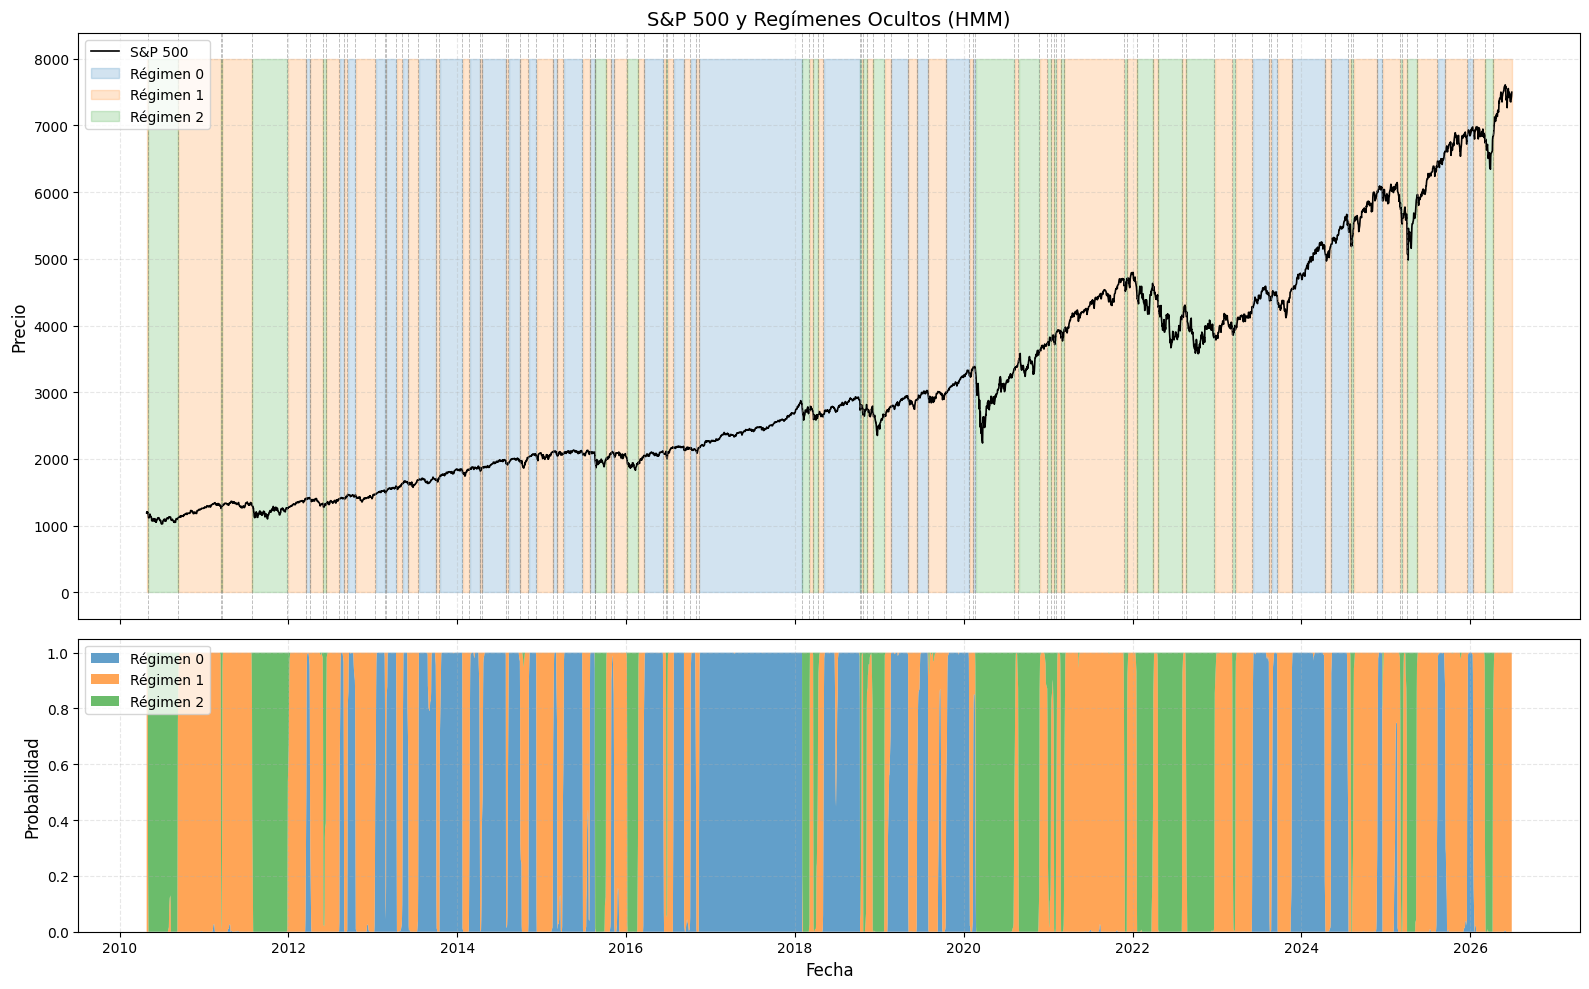

In [119]:
import joblib
import yfinance as yf
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# Cargar modelo y metadatos
ckpt = joblib.load('hmm_production.pkl')
model = ckpt['model']
scaler = ckpt['scaler']
features = ckpt['features']
train_end = ckpt['train_end']

# Descargar todo el histórico igual que en el script original
end_date = (datetime.today() + timedelta(days=1)).strftime('%Y-%m-%d')
raw_spx = yf.download('^GSPC', start='2010-01-01', end=end_date, auto_adjust=True, progress=False)
raw_vix = yf.download('^VIX', start='2010-01-01', end=end_date, auto_adjust=True, progress=False)

if isinstance(raw_spx.columns, pd.MultiIndex):
    raw_spx.columns = raw_spx.columns.get_level_values(0)
if isinstance(raw_vix.columns, pd.MultiIndex):
    raw_vix.columns = raw_vix.columns.get_level_values(0)

data = pd.DataFrame(index=raw_spx.index)
data['Close'] = raw_spx['Close']
data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))
data['vol20'] = data['Returns'].rolling(20).std()
data['vol_ratio'] = data['vol20'] / data['vol20'].rolling(60).std()
data['ret_cum5'] = data['Returns'].rolling(5).sum()
vix_series = raw_vix['Close'].shift(1).reindex(data.index, method='ffill')
data['vix'] = vix_series
data.dropna(inplace=True)

# Escalar y predecir estados (Viterbi) y probabilidades suavizadas
X_scaled = scaler.transform(data[features].values)
states = model.predict(X_scaled)                  # Viterbi (secuencia completa)
posterior = model.predict_proba(X_scaled)         # suavizado forward‑backward

# Gráfico
colores = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}  # adapta si usas más de 3 estados
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(data.index, data['Close'], color='black', linewidth=1.2, label='S&P 500')
for s in np.unique(states):
    mask = states == s
    ax1.fill_between(data.index, 0, data['Close'].max() * 1.05,
                     where=mask, color=colores[s], alpha=0.2,
                     label=f'Régimen {s}')
changes = np.where(np.diff(states) != 0)[0]
for c in changes:
    ax1.axvline(data.index[c], color='gray', linestyle='--', alpha=0.5, linewidth=0.7)
ax1.set_ylabel('Precio', fontsize=12)
ax1.set_title('S&P 500 y Regímenes Ocultos (HMM)', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.3)

ax2.stackplot(data.index, posterior.T,
              colors=[colores[i] for i in range(posterior.shape[1])],
              alpha=0.7, labels=[f'Régimen {i}' for i in range(posterior.shape[1])])
ax2.set_ylabel('Probabilidad', fontsize=12)
ax2.set_xlabel('Fecha', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

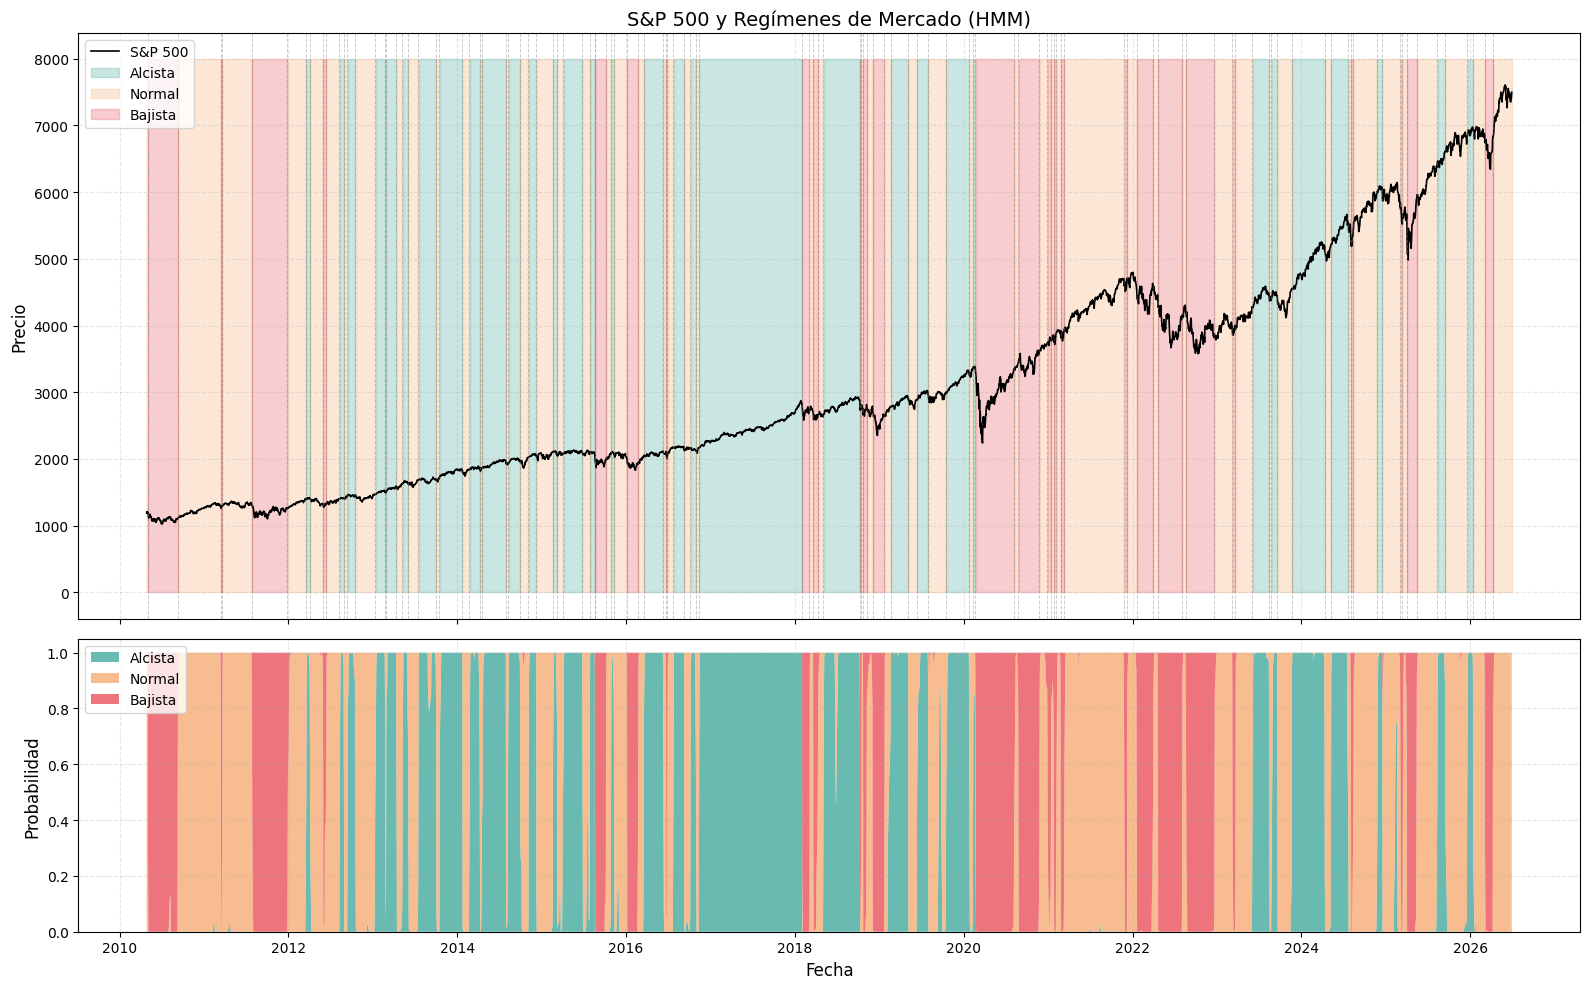


Retorno medio diario por régimen (escala original):
        Alcista: 0.000737  (anualizado: +0.186)
         Normal: 0.000636  (anualizado: +0.160)
        Bajista: -0.000408  (anualizado: -0.103)


In [120]:
import joblib
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# =============================================================================
# 1. Cargar modelo y descargar todo el histórico (igual que en el script original)
# =============================================================================
ckpt = joblib.load('hmm_production.pkl')
model = ckpt['model']
scaler = ckpt['scaler']
features = ckpt['features']
train_end = ckpt['train_end']

end_date = (datetime.today() + timedelta(days=1)).strftime('%Y-%m-%d')
raw_spx = yf.download('^GSPC', start='2010-01-01', end=end_date, auto_adjust=True, progress=False)
raw_vix = yf.download('^VIX', start='2010-01-01', end=end_date, auto_adjust=True, progress=False)

if isinstance(raw_spx.columns, pd.MultiIndex):
    raw_spx.columns = raw_spx.columns.get_level_values(0)
if isinstance(raw_vix.columns, pd.MultiIndex):
    raw_vix.columns = raw_vix.columns.get_level_values(0)

data = pd.DataFrame(index=raw_spx.index)
data['Close'] = raw_spx['Close']
data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))
data['vol20'] = data['Returns'].rolling(20).std()
data['vol_ratio'] = data['vol20'] / data['vol20'].rolling(60).std()
data['ret_cum5'] = data['Returns'].rolling(5).sum()
vix_series = raw_vix['Close'].shift(1).reindex(data.index, method='ffill')
data['vix'] = vix_series
data.dropna(inplace=True)

# =============================================================================
# 2. Escalar y obtener estados + probabilidades suavizadas
# =============================================================================
X_scaled = scaler.transform(data[features].values)
states = model.predict(X_scaled)                # Viterbi (secuencia global)
posterior = model.predict_proba(X_scaled)       # suavizado forward‑backward

# =============================================================================
# 3. Nombres automáticos según retorno medio (en escala original)
# =============================================================================
n_states = model.n_components
# Recuperar media y std del primer feature ('Returns') para desescalar
ret_idx = features.index('Returns')
ret_mean_orig = scaler.mean_[ret_idx]
ret_std_orig = scaler.scale_[ret_idx]

# Media de retorno de cada estado en escala original
state_means_orig = model.means_[:, ret_idx] * ret_std_orig + ret_mean_orig
order = np.argsort(state_means_orig)   # índices de menor a mayor retorno

# Asignar etiquetas según el número de estados
if n_states == 2:
    labels_map = {order[0]: 'Bajista', order[1]: 'Alcista'}
elif n_states == 3:
    labels_map = {order[0]: 'Bajista', order[1]: 'Normal', order[2]: 'Alcista'}
elif n_states == 4:
    labels_map = {order[0]: 'Muy Bajista', order[1]: 'Bajista',
                  order[2]: 'Alcista', order[3]: 'Muy Alcista'}
else:
    # Genérico para más estados
    generic = ['Muy Bajista', 'Bajista', 'Neutral', 'Alcista', 'Muy Alcista', 'Extremo']
    labels_map = {order[i]: generic[i] if i < len(generic) else f'Estado {order[i]}' for i in range(n_states)}

# Lista ordenada de nombres para la leyenda
state_names = [labels_map[i] for i in range(n_states)]

# =============================================================================
# 4. Paleta de colores semántica (asignada por nombre)
# =============================================================================
color_dict = {
    'Muy Bajista': '#8B0000',  # rojo oscuro
    'Bajista': '#E63946',      # rojo
    'Normal': '#F4A261',       # naranja / amarillo
    'Neutral': '#F4A261',
    'Alcista': '#2A9D8F',      # verde azulado
    'Muy Alcista': '#264653',  # verde oscuro
    'Extremo': '#9B5DE5'       # púrpura por si acaso
}
# Asegurar que cada estado tenga un color (si hay estados no mapeados, usar tab10)
default_colors = plt.cm.tab10(np.linspace(0, 1, n_states))
colores = []
for i in range(n_states):
    name = state_names[i]
    if name in color_dict:
        colores.append(color_dict[name])
    else:
        colores.append(default_colors[i])  # fallback

# =============================================================================
# 5. Gráfico
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# Panel 1: Precio + regiones coloreadas por régimen
ax1.plot(data.index, data['Close'], color='black', linewidth=1.2, label='S&P 500')
for s in range(n_states):
    mask = states == s
    ax1.fill_between(data.index, 0, data['Close'].max() * 1.05,
                     where=mask, color=colores[s], alpha=0.25,
                     label=state_names[s])
# Líneas verticales en cambios de estado
changes = np.where(np.diff(states) != 0)[0]
for c in changes:
    ax1.axvline(data.index[c], color='gray', linestyle='--', alpha=0.4, linewidth=0.7)
ax1.set_ylabel('Precio', fontsize=12)
ax1.set_title('S&P 500 y Regímenes de Mercado (HMM)', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.3)

# Panel 2: Probabilidades suavizadas
ax2.stackplot(data.index, posterior.T,
              colors=colores,
              alpha=0.7, labels=state_names)
ax2.set_ylabel('Probabilidad', fontsize=12)
ax2.set_xlabel('Fecha', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Opcional: imprimir las medias de retorno para verificar la asignación
print("\nRetorno medio diario por régimen (escala original):")
for i in range(n_states):
    print(f"   {state_names[i]:>12s}: {state_means_orig[i]:.6f}  (anualizado: {state_means_orig[i]*252:+.3f})")